# 0. Libraries

In [1]:
# 필요한 경우 설치: pandas numpy matplotlib seaborn scipy scikit-learn openpyxl

In [2]:
# 표준 라이브러리
import hashlib
import json
import math
import os
from itertools import combinations
from pathlib import Path

# 데이터 처리 및 파일 입출력
import numpy as np
import openpyxl
import pandas as pd

# 시각화 및 노트북 출력
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

# 통계 및 검증 데이터 분할
from scipy.stats import ks_2samp
from sklearn.model_selection import StratifiedKFold
from scipy.spatial.distance import cdist
from scipy.sparse import csr_matrix

# EDA용 비지도 군집화와 군집 비교
from scipy.cluster.hierarchy import linkage, cut_tree, dendrogram
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score
from threadpoolctl import threadpool_limits


# 1. Load Dataset

## 1.1. 경로 설정

In [3]:
print(os.getcwd())

C:\SeokHwanHong-github-blog\26KAMP


In [4]:
project_root = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / 'data/origin/moldset_labeled_rg3.csv').is_file()
)
os.chdir(project_root)

In [5]:
print(os.getcwd())

C:\SeokHwanHong-github-blog\26KAMP


## 1.2. 데이터 불러오기 및 구조 확인

In [6]:
rg3_l = pd.read_csv('./data/origin/moldset_labeled_rg3.csv', encoding='cp949')

In [7]:
rg3_l.shape

Out[1]: (1182, 26)


In [8]:
rg3_l.head(10)

Out[1]: 
   Unnamed: 0  PassOrFail  ...  Mold_Temperature_3  Mold_Temperature_4
0        1211           0  ...           -1.393485           -1.576042
1        1212           0  ...           -1.393485           -1.576042
2        1213           0  ...           -1.535968           -1.576042
3        1214           0  ...           -1.535968           -1.576042
4        1215           0  ...           -1.535968           -1.576042
5        1216           0  ...           -1.535968           -1.576042
6        1217           0  ...           -1.393485           -1.576042
7        1218           0  ...           -1.393485           -1.576042
8        1219           0  ...           -1.393485           -1.576042
9        1220           0  ...           -1.393485           -1.576042

[10 rows x 26 columns]


## 1.3. 컬럼 확인

In [9]:
rg3_l.columns

Out[1]: 
Index(['Unnamed: 0', 'PassOrFail', 'Injection_Time', 'Filling_Time',
       'Plasticizing_Time', 'Cycle_Time', 'Clamp_Close_Time',
       'Cushion_Position', 'Plasticizing_Position', 'Clamp_Open_Position',
       'Max_Injection_Speed', 'Max_Screw_RPM', 'Average_Screw_RPM',
       'Max_Injection_Pressure', 'Max_Switch_Over_Pressure',
       'Max_Back_Pressure', 'Average_Back_Pressure', 'Barrel_Temperature_1',
       'Barrel_Temperature_2', 'Barrel_Temperature_3', 'Barrel_Temperature_4',
       'Barrel_Temperature_5', 'Barrel_Temperature_6', 'Hopper_Temperature',
       'Mold_Temperature_3', 'Mold_Temperature_4'],
      dtype='object')


#### 가이드북 p.20 참고


* 'Unnamed: 0': 인덱스 번호

* 'PassOrFail': 사출되는 각 물품마다 검수자가 양품 선별을 하여 붙이는 레이블 값

* 'Injection_Time'(Sec (초)): 고압+사출시간(고압(사출압): 재료를 금형에 유입시킬때의 압력, 사출시간: 재료를 금형에 유입시키는데 소요되는 시간)

* 'Filling_Time'(Sec (초)): 충진시간으로 사출기에서 금형으로 내용물이 주입되는 시간

* 'Plasticizing_Time'(Sec (초)): 계량시간으로 재료를 스크류에 1번 생산할 만큼 용융되어 저장되는 시간

* 'Cycle_Time'(Sec (초)): 1번의 제품생산에 소요되는 생산시간

* 'Clamp_Close_Time'(Sec (초)): 제품이 생산되고 난후 열려있는 금형을 사출기가 닫아주고 빈틈이 없이 고정축과 이동축을 꽉 잡아주는데 걸리는 시간

* 'Cushion_Position'(mm): 보압(사출압의 다음으로 가해지는 압력(금형내부압력을 조절하여 과충전을방지))을 하기위한 스크류의 위치

* 'Plasticizing_Position'(mm): 계량완료위치(계량을 마친 스크류의 위치)

* 'Clamp_Open_Position'(mm): 제품이 생산되어 추출하기위해 금형이 열리고 난 위치

* 'Max_Injection_Speed'(mm/s): 배럴에 계량되어 있는 용융수지가 금형으로 흘러들어가는데 측정되는 최대 속도

* 'Max_Screw_RPM'(mm/s): 사출을 위한 스크류의 최대속도

* 'Average_Screw_RPM'(mm/s): 사출을 위한 스크류의 평균속도

* 'Max_Injection_Pressure'(MPa): 배럴에 계량되어 있는 용융수지가 금형으로 흘러들어가는데 가해지는 최대 압력

* 'Max_Switch_Over_Pressure'(MPa): 사출에서 보압(충진된 수지가 밀리지않게 압력을준다)으로 변환되는 압력

* 'Max_Back_Pressure'(MPa): 수지가 계량이 되는중에 스크류가 밀려나는 현상을 저지하기위한 최대압력

* 'Average_Back_Pressure'(MPa): 수지가 계량이 되는중에 스크류가 밀려나는 현상을 저지하기위한 평균압력

* 'Barrel_Temperature_1~6'(섭씨 (°C)): 계량 및 사출시 수지가 일정하게 용융(녹임)을 유지하기위해 온도가 일정해야한다

* 'Hopper_Temperature'(섭씨 (°C)): 재료주입구의 온도(충분히 건조시켜주며 재료가 용융되는시간을 절약시켜 주기위해 온도가 높아야한다)

* 'Mold_Temperature_3, 4'(섭씨 (°C)): 재료주입구의 온도(충분히 건조시켜주며 재료가 용융되는시간을 절약시켜 주기위해 온도가 높아야한다)

# 2. EDA

## 2.1. 통계량 확인

In [10]:
rg3_l.describe()

Out[1]: 
        Unnamed: 0   PassOrFail  ...  Mold_Temperature_3  Mold_Temperature_4
count  1182.000000  1182.000000  ...        1.182000e+03        1.182000e+03
mean   1801.500000     0.021151  ...       -3.847270e-16        4.809088e-17
std     341.358316     0.143947  ...        1.000423e+00        1.000423e+00
min    1211.000000     0.000000  ...       -1.963415e+00       -2.061609e+00
25%    1506.250000     0.000000  ...       -8.235546e-01       -8.476893e-01
50%    1801.500000     0.000000  ...        1.738253e-01        2.053097e-03
75%    2096.750000     0.000000  ...        9.930992e-01        1.094583e+00
max    2392.000000     1.000000  ...        1.598652e+00        1.822933e+00

[8 rows x 26 columns]


In [11]:
rg3_l = rg3_l.drop(columns = ['Unnamed: 0'])

In [12]:
rg3_l.describe()

Out[1]: 
        PassOrFail  Injection_Time  ...  Mold_Temperature_3  Mold_Temperature_4
count  1182.000000    1.182000e+03  ...        1.182000e+03        1.182000e+03
mean      0.021151   -4.715311e-14  ...       -3.847270e-16        4.809088e-17
std       0.143947    1.000423e+00  ...        1.000423e+00        1.000423e+00
min       0.000000   -8.627730e+00  ...       -1.963415e+00       -2.061609e+00
25%       0.000000   -2.909945e-02  ...       -8.235546e-01       -8.476893e-01
50%       0.000000   -2.909945e-02  ...        1.738253e-01        2.053097e-03
75%       0.000000   -2.909945e-02  ...        9.930992e-01        1.094583e+00
max       1.000000    8.569634e+00  ...        1.598652e+00        1.822933e+00

[8 rows x 25 columns]


**통계량 해석:** 이 표는 양품과 불량을 합친 전체 분포이므로 평균·범위만으로 불량 조건을 정할 수 없다. 특히 반복된 공정조건이 통계량에 중복 반영될 수 있다. 다음 절에서는 동일 공정값의 반복과 라벨 충돌을 먼저 확인한다.

In [13]:
# 종속변수 & 독립변수 분리

rg3_l_y = rg3_l['PassOrFail']
rg3_l_x = rg3_l.drop(columns = ['PassOrFail'])

## 2.2. 데이터 중복 확인

**중복 처리 비교의 목적:** CN7과 같은 순서로, 불량을 우선하여 동일 공정조건을 하나로 축약한 데이터의 분포를 먼저 확인한다. 이 처리는 충돌 양품을 제거하므로 최종 학습 데이터 정책은 아니다. 3절에서는 원본을 복원해 라벨 공존을 확인하고, 4절에서 최종 처리 기준을 결정한다.

In [14]:
temp = rg3_l_x.copy()
temp["PassOrFail"] = rg3_l_y


# 불량(1)이 먼저 오도록 정렬
temp = temp.sort_values(
    by="PassOrFail",
    ascending=False
)

# 독립변수가 동일한 경우
# 불량을 우선적으로 하나만 남김
temp_dedup = temp.drop_duplicates(
    subset=rg3_l_x.columns.tolist(),
    keep="first"
)

# 원래 index 기준으로 정렬
temp_dedup = temp_dedup.sort_index()

rg3_l_x = temp_dedup.drop(columns="PassOrFail")
rg3_l_y = temp_dedup["PassOrFail"]

**중복 처리의 의미:** 원본 1,182행(양품 1,157·불량 25)은 불량 우선 처리 후 591개 조건(양품 566·불량 25)이 된다. 각 전체입력 패턴은 정확히 2회씩 기록되어 있으며, 25개 패턴은 양품 1행·불량 1행으로 구성된다. 불량 우선 처리는 이 25개 양품을 제거한다. 따라서 이 처리 후의 분포와 불량 비율은 원본과 다르며, 분리 가능성이나 원본 발생률로 해석하지 않는다.

## 2.3. 컬럼별 데이터 확인

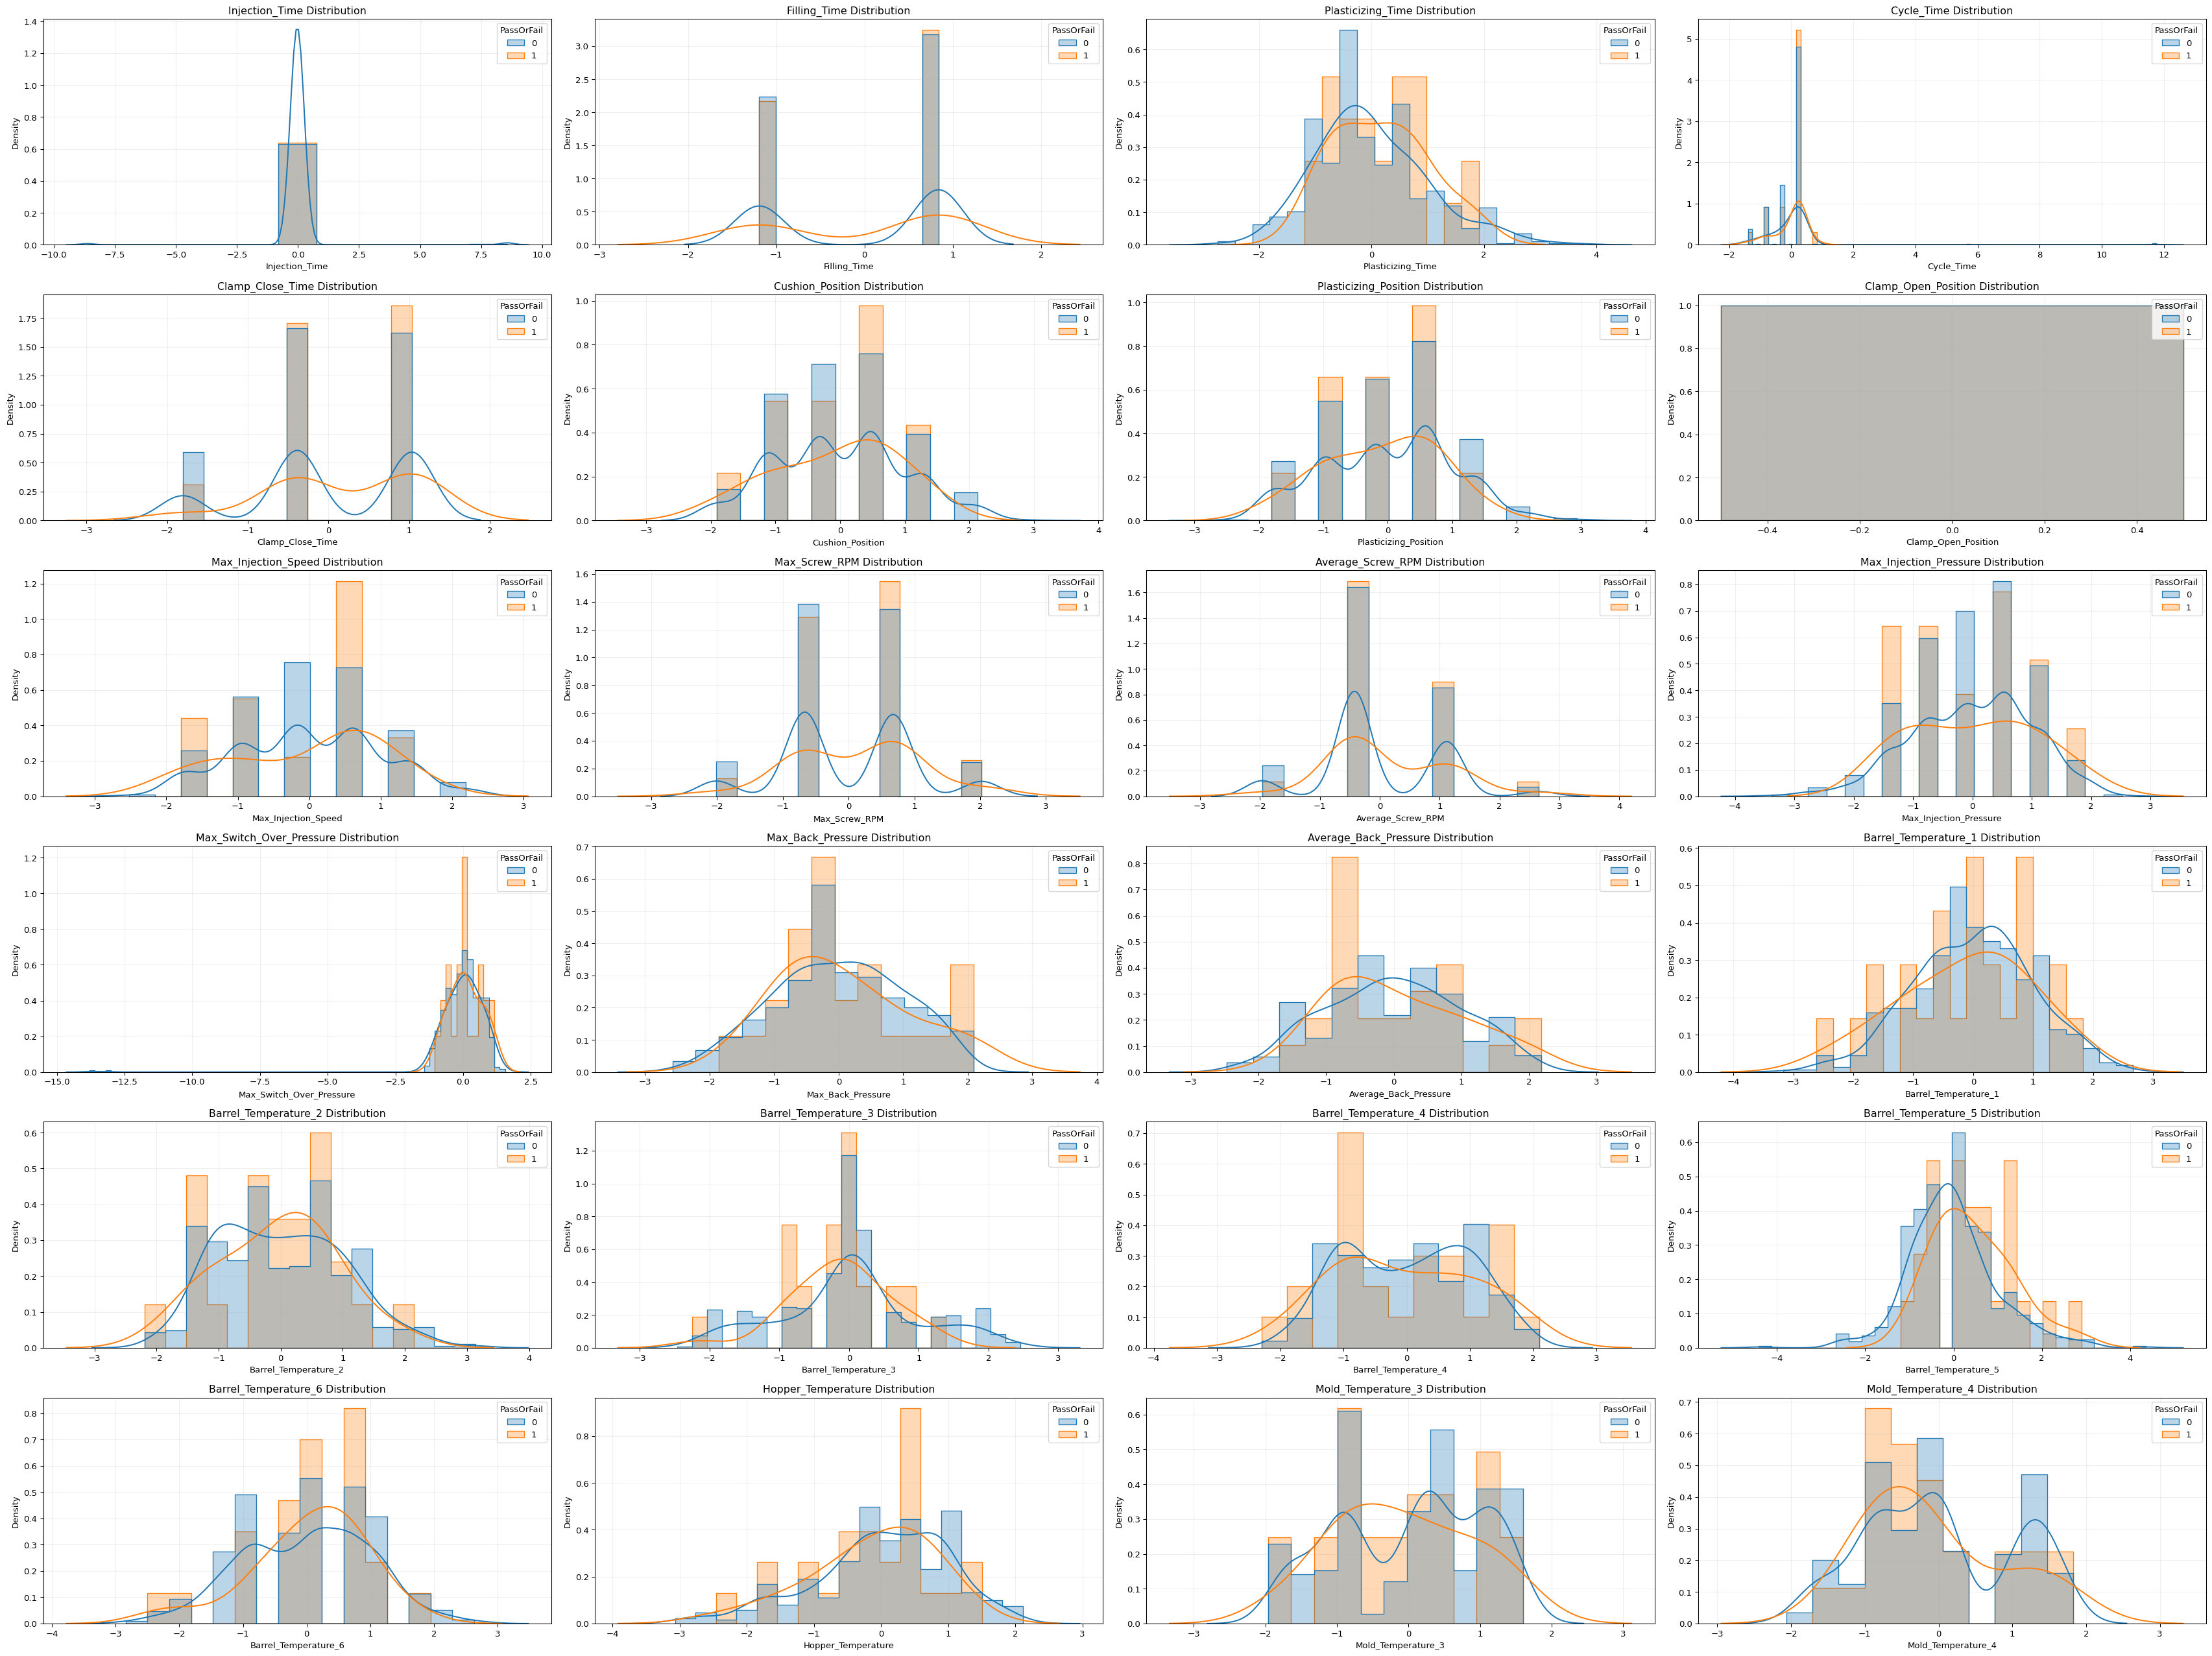

In [15]:



plot_df = rg3_l_x.copy()
plot_df["PassOrFail"] = rg3_l_y.values

# 숫자형 변수만 선택
numeric_cols = rg3_l_x.select_dtypes(include="number").columns

# 그래프 설정
n_cols = 4
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(36, 4.5 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(numeric_cols):

    ax = axes[i]

    # -------------------------
    # 1. Histogram
    # -------------------------
    sns.histplot(
        data=plot_df,
        x=col,
        hue="PassOrFail",
        stat="density",
        common_norm=False,
        element="step",
        alpha=0.3,
        kde=False,          # KDE는 따로 처리
        ax=ax
    )

    # -------------------------
    # 2. 클래스별 KDE
    # -------------------------
    for label in plot_df["PassOrFail"].dropna().unique():

        values = (
            plot_df.loc[
                plot_df["PassOrFail"] == label,
                col
            ]
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
        )

        # KDE가 가능한 경우만 수행
        if (
            len(values) >= 3
            and values.nunique() >= 2
            and values.std() > 1e-10
        ):
            try:
                sns.kdeplot(
                    x=values,
                    ax=ax,
                    label=f"{label} KDE"
                )
            except Exception:
                pass

    ax.set_title(f"{col} Distribution")
    ax.set_xlabel(col)
    ax.set_ylabel("Density")
    ax.grid(alpha=0.2)

# 남는 subplot 제거
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [16]:
# KS 통계량 확인
# KS 통계량: 두 누적 분포 함수의 최대 거리 차이를 측정하는 비모수적 통계량

ks_results = []

numeric_cols = rg3_l_x.select_dtypes(include="number").columns

for col in numeric_cols:
    normal = rg3_l_x.loc[rg3_l_y == 0, col].dropna()
    abnormal = rg3_l_x.loc[rg3_l_y == 1, col].dropna()

    # 두 그룹 중 하나라도 데이터가 없으면 제외
    if len(normal) == 0 or len(abnormal) == 0:
        continue

    ks_stat, p_value = ks_2samp(
        normal,
        abnormal
    )

    ks_results.append({
        "Feature": col,
        "Normal_Median": normal.median(),
        "Abnormal_Median": abnormal.median(),
        "Normal_IQR": normal.quantile(0.75) - normal.quantile(0.25),
        "Abnormal_IQR": abnormal.quantile(0.75) - abnormal.quantile(0.25),
        "KS_Statistic": ks_stat,
        "P_Value": p_value,
        "Normal_Count": len(normal),
        "Abnormal_Count": len(abnormal)
    })

ks_df = (
    pd.DataFrame(ks_results)
    .sort_values("KS_Statistic", ascending=False)
    .reset_index(drop=True)
)

ks_df["Rank"] = ks_df.index + 1

ks_df = ks_df[
    [
        "Rank",
        "Feature",
        "KS_Statistic",
        "P_Value",
        "Normal_Median",
        "Abnormal_Median",
        "Normal_IQR",
        "Abnormal_IQR",
        "Normal_Count",
        "Abnormal_Count"
    ]
]

ks_df

Out[1]: 
    Rank                   Feature  ...  Normal_Count  Abnormal_Count
0      1      Barrel_Temperature_5  ...           566              25
1      2        Mold_Temperature_4  ...           566              25
2      3        Hopper_Temperature  ...           566              25
3      4        Mold_Temperature_3  ...           566              25
4      5       Max_Injection_Speed  ...           566              25
5      6         Plasticizing_Time  ...           566              25
6      7     Average_Back_Pressure  ...           566              25
7      8      Barrel_Temperature_3  ...           566              25
8      9      Barrel_Temperature_6  ...           566              25
9     10      Barrel_Temperature_4  ...           566              25
10    11                Cycle_Time  ...           566              25
11    12      Barrel_Temperature_1  ...           566              25
12    13      Barrel_Temperature_2  ...           566              25
13    14   

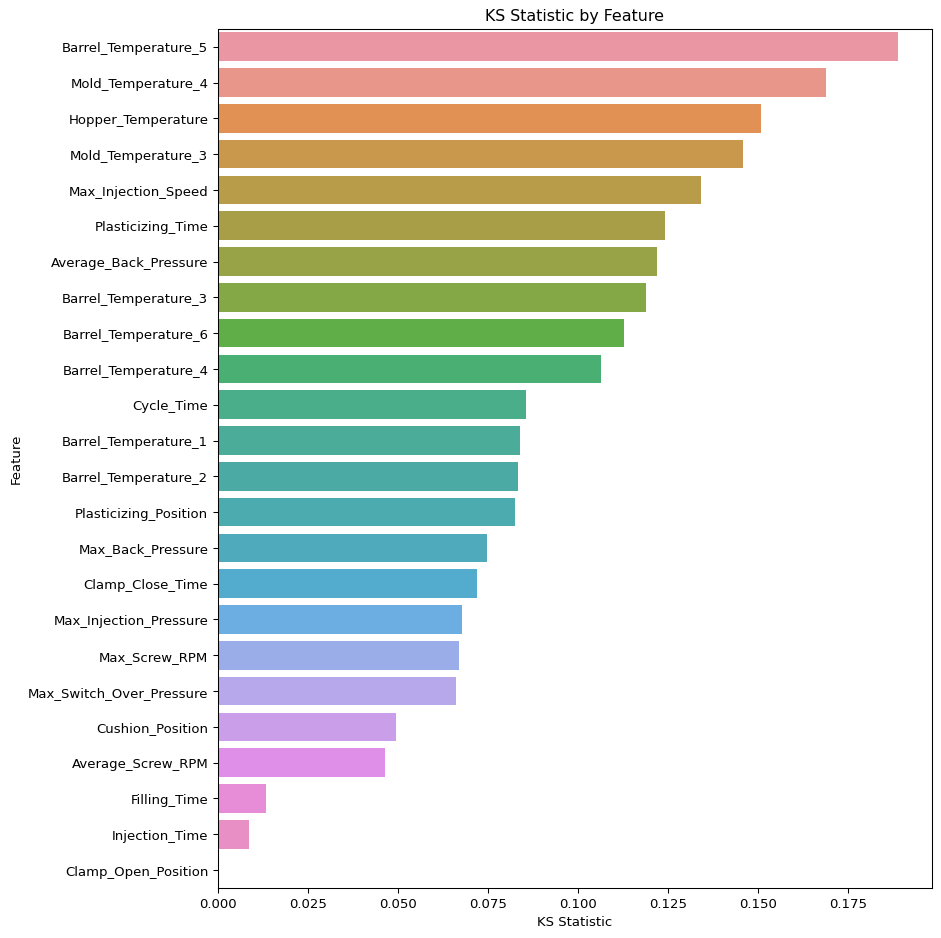

In [17]:
plt.figure(figsize=(10, 10))

sns.barplot(
    data=ks_df,
    x="KS_Statistic",
    y="Feature"
)

plt.title("KS Statistic by Feature")
plt.xlabel("KS Statistic")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

**분포·KS 결과 해석:** 기존 처리에서 상위 KS는 배럴 온도 5 0.189, 금형 온도 4 0.169, 호퍼 온도 0.151, 금형 온도 3 0.146, 최대 사출 속도 0.134이다. 개별 분포 차이는 크지 않으며, 상대적 순위를 더 탐색하는 것만으로 전처리·개선 결정을 내리기 어렵다. KS 계산 자체가 부적합하다는 뜻이 아니라, 분석의 중심 질문을 바꾼다는 뜻이다.

다음 3절은 **반복·라벨 구조 → 라벨·비라벨 범위 차이 → 분할 그룹 점검 → 전처리 결정** 순서로 진행한다. 기존 KS 상위 조합과 공정별 분포는 부록 A에 보존한다.

# 3. 데이터 구조와 전처리 기준을 확인하는 EDA

**목표:** 반복·라벨 충돌, 라벨·비라벨의 값 종류와 범위, 분할 간 동일 패턴의 겹침을 확인하고 전처리 기준을 정한다.

분석 순서는 **반복 구조 → 값 종류·관측 범위 → 분할 그룹 점검 → 처리 결정**이다. 관측된 데이터 구조와 제조 불량의 인과적 원인은 구분하며, 비라벨 데이터에 불량 정답을 부여하지 않는다.

추가 분석은 **이산 조합 조건군 → 조건군별 충돌 → 기존 집중 구간의 조건군 내 비교 → 주변 조건 구성 → 비라벨 범위 이탈 분해** 순서로 진행한다.

## 3.1 반복 구조와 관측 라벨의 식별 한계

동일 조건의 반복이 실제 생산 반복인지 복제·가공의 결과인지 현재 CSV만으로 확정하지 않는다. 먼저 관측된 구조를 기록하고, 입력으로 사용하면 안 되는 정보와 보존할 라벨을 구분한다.

,patterns,rows,normal,defects
type,,,,
conflicting,25,50,25,25
normal_only,566,1132,1132,0


,row_gap,label_order,patterns
0,1,"0,0",549
3,2,"0,0",8
2,3,"0,0",9
4,1,"0,1",2
1,1,"1,0",23


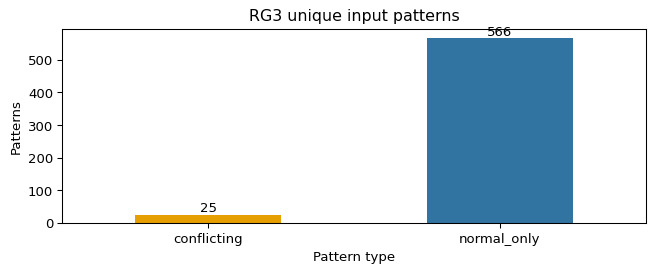

In [18]:
audit_root = next(p for p in [Path.cwd(), *Path.cwd().parents]
                  if (p / 'data/origin/moldset_labeled_rg3.csv').is_file())
audit_labeled = pd.read_csv(audit_root / 'data/origin/moldset_labeled_rg3.csv')
audit_unlabeled = pd.read_csv(audit_root / 'data/origin/moldset_unlabeled_rg3.csv')
audit_features = [c for c in audit_labeled if c not in ['Unnamed: 0', 'PassOrFail']]
audit_X = audit_labeled[audit_features].copy()
audit_y = audit_labeled.PassOrFail.copy()
audit_groups = pd.Series(pd.MultiIndex.from_frame(audit_X).factorize(sort=False)[0], name='pattern_id')
audit_work = audit_labeled.assign(pattern_id=audit_groups, row_position=np.arange(len(audit_X)))
audit_patterns = audit_work.groupby('pattern_id').agg(
    rows=('PassOrFail','size'), defects=('PassOrFail','sum'),
    source_ids=('Unnamed: 0',list), positions=('row_position',list), labels=('PassOrFail',list))
audit_patterns['normal'] = audit_patterns.rows - audit_patterns.defects
audit_patterns['type'] = np.select([audit_patterns.defects.eq(0),audit_patterns.normal.eq(0)],
                                     ['normal_only','defect_only'],default='conflicting')
audit_pattern_summary = audit_patterns.groupby('type').agg(
    patterns=('rows','size'),rows=('rows','sum'),normal=('normal','sum'),defects=('defects','sum'))
display(audit_pattern_summary)
assert audit_patterns.rows.eq(2).all()
audit_pair_structure = pd.DataFrame({
    'row_gap': audit_patterns.positions.map(lambda a:a[1]-a[0]),
    'label_order': audit_patterns.labels.map(lambda a:','.join(map(str,a))),
}).value_counts().rename('patterns').reset_index().sort_values(['label_order','row_gap'])
display(audit_pair_structure)
fig,ax=plt.subplots(figsize=(7,3))
audit_pattern_summary.patterns.plot.bar(ax=ax,rot=0,color=['#E69F00','#3274A1'])
ax.set(title='RG3 unique input patterns',ylabel='Patterns',xlabel='Pattern type')
for container in ax.containers: ax.bar_label(container)
plt.tight_layout();plt.show()

**결과와 판단:** 591개 패턴 모두 2행이며, 566개는 양품·양품, 25개는 양품·불량이다. 574개 패턴은 원본 행 위치가 인접한다. 충돌 25개 중 불량이 먼저 기록된 패턴은 23개, 나중인 패턴은 2개다. 가까운 행과 기록 순서에 구조가 있지만, ID가 생산 시간이라는 근거나 데이터 생성 과정의 설명은 없다. 행 번호·홀짝·중복 내 순서를 특징으로 넣지 않는다.

동일한 24개 공정값에 서로 다른 라벨이 있으므로, 현재 기록만으로 두 행의 차이를 설명할 수 없다. 추가적인 기록·검수 정보의 확인이 필요하다.

**처리 결정:** 원본 라벨을 보존하고 전체입력 패턴을 검증 그룹으로 사용한다. 불량 우선 중복 제거는 '한 번이라도 불량이 나온 조건'으로 목표를 바꾸므로 기본 전처리로 확정하지 않는다. 원인 규명을 위해서는 동일 패턴 두 행의 생성·검수·반복 기록 기준을 우선 확인해야 한다.

## 3.2 학습 데이터와 적용 데이터의 값 종류·범위 차이

평균과 표준편차가 비슷하다는 것만으로 같은 분포나 같은 물리 조건이라고 볼 수 없다. 각 파일의 고유값 수와 표준화 좌표상 관측 범위를 비교한다. 이 단계는 적용 범위 점검이며, 비라벨 행의 이상·불량 판정이 아니다.

,feature,labeled_unique,unlabeled_unique,labeled_mean,unlabeled_mean,labeled_std_ddof0,unlabeled_std_ddof0,unlabeled_outside_labeled_range
0,Injection_Time,3,91,-0.0,0.0,1.0,1.0,0.0000
1,Filling_Time,2,97,-0.0,0.0,1.0,1.0,0.3658
2,Plasticizing_Time,27,470,-0.0,0.0,1.0,1.0,0.0004
3,Cycle_Time,10,371,0.0,0.0,1.0,1.0,0.1159
4,Clamp_Close_Time,3,88,0.0,-0.0,1.0,1.0,0.0002
5,Cushion_Position,7,68,0.0,-0.0,1.0,1.0,0.0000
6,Plasticizing_Position,8,207,0.0,0.0,1.0,1.0,0.0001
7,Clamp_Open_Position,1,53,0.0,0.0,0.0,1.0,1.0000
8,Max_Injection_Speed,7,179,-0.0,0.0,1.0,1.0,0.0000
9,Max_Screw_RPM,4,28,-0.0,-0.0,1.0,1.0,0.0722


,dataset,rows,unique_input_patterns
0,labeled,1182,591
1,unlabeled,35941,29707


**학습 상수열을 제외한 범위 점검:** 18,416/35,941행 (51.24%)이 적어도 한 변수에서 라벨 데이터의 관측 범위 밖이다.

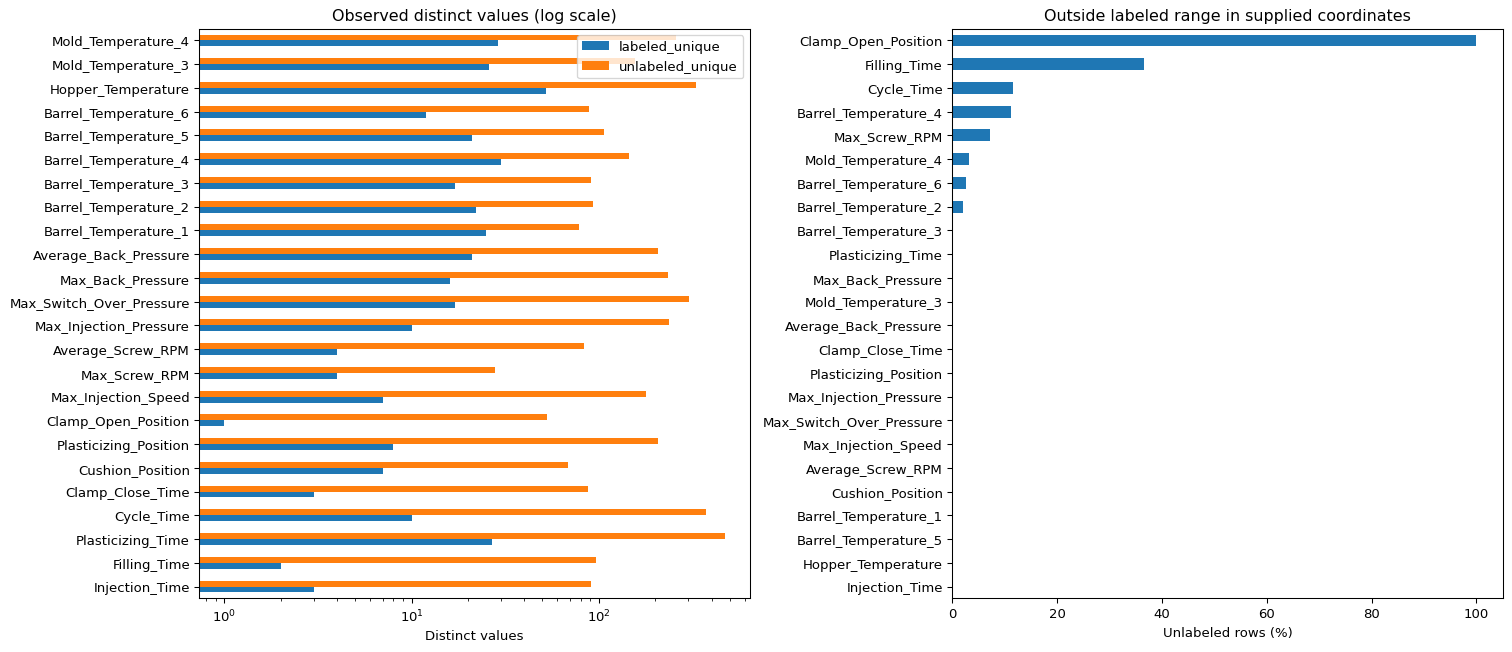

In [19]:
audit_U = audit_unlabeled[audit_features]
audit_outside = audit_U.lt(audit_X.min()) | audit_U.gt(audit_X.max())
audit_coverage = pd.DataFrame({
    'feature':audit_features,
    'labeled_unique':audit_X.nunique().values,'unlabeled_unique':audit_U.nunique().values,
    'labeled_mean':audit_X.mean().values,'unlabeled_mean':audit_U.mean().values,
    'labeled_std_ddof0':audit_X.std(ddof=0).values,'unlabeled_std_ddof0':audit_U.std(ddof=0).values,
    'unlabeled_outside_labeled_range':audit_outside.mean().values,
})
display(audit_coverage.round(4))
audit_active = audit_X.columns[audit_X.nunique().gt(1)]
audit_outside_rows = audit_outside[audit_active].any(axis=1)
display(pd.DataFrame([
    ['labeled',len(audit_X),len(audit_X.drop_duplicates())],
    ['unlabeled',len(audit_U),len(audit_U.drop_duplicates())],
],columns=['dataset','rows','unique_input_patterns']))
display(Markdown('**학습 상수열을 제외한 범위 점검:** ' +
    f'{int(audit_outside_rows.sum()):,}/{len(audit_U):,}행 '
    f'({audit_outside_rows.mean():.2%})이 적어도 한 변수에서 라벨 데이터의 관측 범위 밖이다.'))
fig,axes=plt.subplots(1,2,figsize=(16,7))
audit_coverage.set_index('feature')[['labeled_unique','unlabeled_unique']].plot.barh(ax=axes[0],logx=True)
axes[0].set(title='Observed distinct values (log scale)',xlabel='Distinct values',ylabel='')
(100*audit_coverage.set_index('feature').unlabeled_outside_labeled_range).sort_values().plot.barh(ax=axes[1])
axes[1].set(title='Outside labeled range in supplied coordinates',xlabel='Unlabeled rows (%)',ylabel='')
plt.tight_layout();plt.show()

**결과와 판단:** 충전시간은 라벨 데이터에서 고유값 2개, 비라벨에서 97개이고, 사출시간은 3개 대 91개다. 라벨 데이터의 591개 조건에 비해 비라벨은 29,707개 고유 조건이다. 라벨 데이터가 실제 공정조건의 변화를 충분히 대표하는지 확인할 필요가 있다. 더 적은 행 수가 고유값 수 차이의 일부를 설명할 수 있으므로, 이 수치만으로 측정 정밀도나 생성 방식을 확정하지 않는다.

두 파일은 상수열을 제외한 평균이 거의 0, 모집단 표준편차가 거의 1이다. 파일별 표준화와 일치하는 수치지만, 원래 물리 단위의 정규화 계수는 이 분석으로 복원할 수 없다. 같은 숫자 임계값을 물리 규격으로 해석하지 않는다.

`Clamp_Open_Position`은 학습에서 상수인 반면 비라벨에서는 53개 값으로 변하며, 비라벨의 모든 값이 학습의 단일 값과 다르다. 이 열을 제외해도 **18,416/35,941행(51.24%)**이 하나 이상의 학습 관측 범위를 벗어난다. 이는 제공 좌표계의 적용 범위 차이이며, 실제 공정 이상이 51.24%라는 의미가 아니다.

**처리 결정:** 공통 원본 24열을 보존하고 라벨 데이터의 상수열을 명세에 기록한다. 비라벨을 별도로 다시 표준화하거나 라벨 관측 범위로 강제 클리핑하지 않는다. 범위 밖 비율은 데이터 적용 범위 점검 지표로 남긴다. 원본 단위·정규화 계수·데이터 생성 기준을 확인해야 한다.

## 3.3 분할 방식이 만드는 검증 실패

같은 데이터에 대해 행 단위 층화 분할과 패턴 단위 층화 분할을 비교한다. 모델 점수의 유불리가 아니라, 검증이 '처음 보는 조건'을 평가하는지부터 확인한다. 랜덤 시드는 42, 폴드는 3개로 고정한다.

,scheme,fold,valid_rows,valid_defects,rows_with_seen_pattern,defects_with_seen_pattern
0,row_stratified,0,394,8,270,7
1,row_stratified,1,394,8,258,7
2,row_stratified,2,394,9,266,8
3,pattern_grouped,0,394,8,0,0
4,pattern_grouped,1,394,8,0,0
5,pattern_grouped,2,394,9,0,0


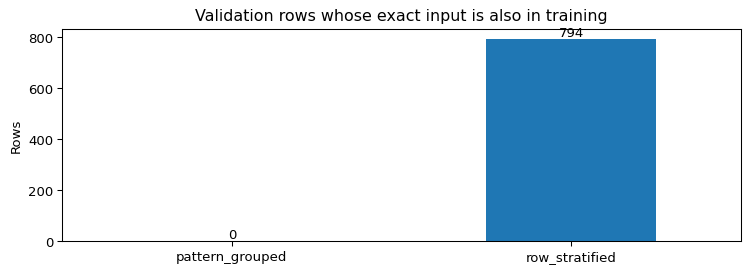

In [20]:
audit_splitter=StratifiedKFold(n_splits=3,shuffle=True,random_state=42)
audit_pattern_fold=pd.Series(-1,index=audit_patterns.index,dtype='int64')
for k,(_,va) in enumerate(audit_splitter.split(np.zeros((len(audit_patterns),1)),audit_patterns.type)):
    audit_pattern_fold.iloc[va]=k
audit_folds=audit_groups.map(audit_pattern_fold)
audit_split_rows=[]
for scheme in ['row_stratified','pattern_grouped']:
    splits=(audit_splitter.split(audit_X,audit_y) if scheme=='row_stratified' else
            ((np.flatnonzero(audit_folds.ne(k)),np.flatnonzero(audit_folds.eq(k))) for k in range(3)))
    for k,(tr,va) in enumerate(splits):
        seen=audit_groups.iloc[va].isin(audit_groups.iloc[tr]).to_numpy()
        bad=audit_y.iloc[va].eq(1).to_numpy()
        audit_split_rows.append([scheme,k,len(va),int(bad.sum()),int(seen.sum()),int((seen & bad).sum())])
        if scheme=='pattern_grouped': assert not seen.any()
audit_split_table=pd.DataFrame(audit_split_rows,columns=[
    'scheme','fold','valid_rows','valid_defects','rows_with_seen_pattern','defects_with_seen_pattern'])
display(audit_split_table)
fig,ax=plt.subplots(figsize=(8,3))
audit_split_table.groupby('scheme').rows_with_seen_pattern.sum().plot.bar(ax=ax,rot=0)
ax.set(title='Validation rows whose exact input is also in training',ylabel='Rows',xlabel='')
for container in ax.containers:ax.bar_label(container)
plt.tight_layout();plt.show()

**결과와 판단:** 행 분할에서는 검증 전체 1,182행 중 **794행(67.17%)**, 불량 25행 중 **22행**이 학습에 같은 입력을 가진다. 그룹 분할에서는 두 수치 모두 0이다. 특히 불량과 다른 라벨의 양품 짝이 학습에 들어가는 경우도 있으므로, 중복 분할이 반드시 점수를 올린다고 단정하지 않는다. 확실한 문제는 새 공정조건에 대한 일반화와 이미 본 조건의 재등장이 섞인다는 점이다.

**처리 결정:** 이후 실험은 동일한 패턴 그룹 폴드를 사용한다. ID에 시간 의미가 확인되기 전에는 시간 검증이라고 부르지 않는다. 그룹 검증도 비라벨 파일의 조건 다양성·정규화 차이를 재현하는 것은 아니므로, 적용 데이터 성능을 보장하지 않는다.

## 3.4 이산 조합으로 관측 조건군 정의

**질문:** 충전시간 2개 값과 사출시간 3개 값이 실제로 어떤 조합으로 나타나는가? 최대 6개 조합을 확인하고, 관측 조합별 다른 공정값의 중앙값을 비교한다. 분석 단위는 원본 행이 아니라 591개 고유 전체입력 패턴이다.

조건군은 두 변수의 관측 조합에 붙인 이름이다. 이를 실제 생산 모드·설비 상태로 단정하거나 비라벨 데이터에 같은 물리 조건군으로 적용하지 않는다.

,Filling_Time,Injection_Time,patterns,original_rows
condition_group,,,,
G1,-1.192531,-8.627730,3,6
G2,-1.192531,-0.029099,241,482
G3,0.838552,-0.029099,342,684
G4,0.838552,8.569634,5,10


,Max_Injection_Speed,Max_Back_Pressure,Plasticizing_Time,Cushion_Position,Barrel_Temperature_5,Mold_Temperature_3
condition_group,,,,,,
G1,2.188,-1.019,0.855,-1.114,-0.344,-1.536
G2,0.618,-0.708,0.182,0.480,-0.031,-0.254
G3,-0.952,0.536,-0.267,-0.317,-0.031,0.388
G4,-1.737,1.470,-0.940,2.075,-0.344,1.171


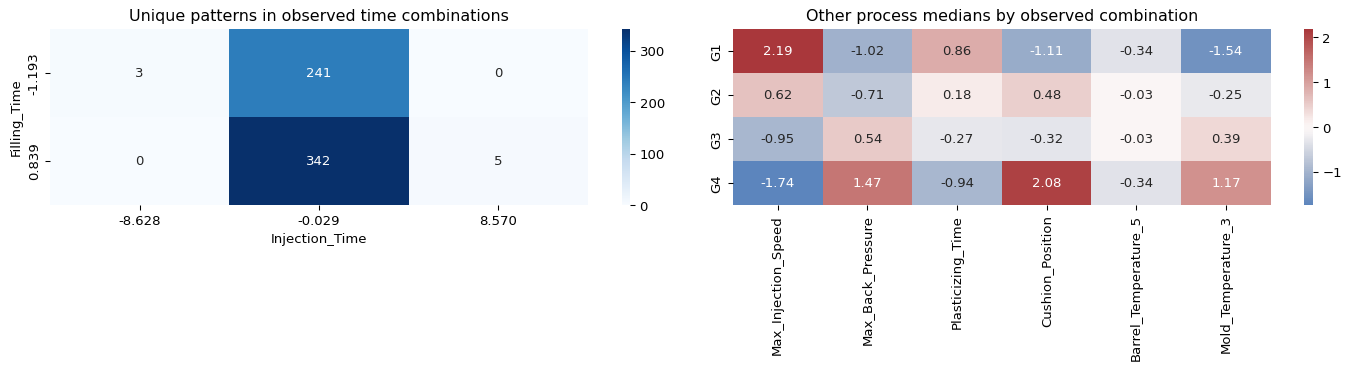

In [21]:
structure_keys=['Filling_Time','Injection_Time']
structure_patterns=audit_work.drop_duplicates(audit_features).set_index('pattern_id')[audit_features].copy()
structure_patterns['conflicting']=audit_patterns.type.eq('conflicting').astype(int)
structure_combos=structure_patterns[structure_keys].drop_duplicates().sort_values(structure_keys)
structure_lookup={tuple(values):f'G{i+1}' for i,values in enumerate(structure_combos.to_numpy())}
structure_patterns['condition_group']=[structure_lookup[tuple(v)] for v in structure_patterns[structure_keys].to_numpy()]
structure_groups=structure_patterns.groupby('condition_group').agg(
    Filling_Time=('Filling_Time','first'),Injection_Time=('Injection_Time','first'),
    patterns=('conflicting','size'))
structure_groups['original_rows']=2*structure_groups.patterns
display(structure_groups)
structure_count_grid=structure_patterns.groupby(structure_keys).size().unstack('Injection_Time').reindex(
    index=sorted(structure_patterns.Filling_Time.unique()),columns=sorted(structure_patterns.Injection_Time.unique())).fillna(0).astype(int)
structure_context=['Max_Injection_Speed','Max_Back_Pressure','Plasticizing_Time',
                   'Cushion_Position','Barrel_Temperature_5','Mold_Temperature_3']
structure_medians=structure_patterns.groupby('condition_group')[structure_context].median()
display(structure_medians.round(3))
fig,axes=plt.subplots(1,2,figsize=(15,4))
sns.heatmap(structure_count_grid,annot=True,fmt='d',cmap='Blues',ax=axes[0],
    xticklabels=[f'{v:.3f}' for v in structure_count_grid.columns],
    yticklabels=[f'{v:.3f}' for v in structure_count_grid.index])
axes[0].set(title='Unique patterns in observed time combinations')
sns.heatmap(structure_medians,annot=True,fmt='.2f',cmap='vlag',center=0,ax=axes[1])
axes[1].set(title='Other process medians by observed combination',ylabel='')
plt.tight_layout();plt.show()

**결과와 해석:** 6개 가능한 조합 중 4개만 관측된다. G1·G4는 사출시간의 양 끝 값에 해당하며 각각 3개·5개 패턴뿐이다. 같은 중앙 사출시간을 갖는 G2·G3가 각각 241개·342개 패턴으로 전체의 대부분을 차지한다. 이 두 조건군은 충전시간 값으로 구분된다.

G2의 최대 사출 속도 중앙값은 0.618, 배압은 -0.708이고, G3는 각각 -0.952, 0.536이다. 즉 충전시간의 두 값은 다른 공정값의 변화와 함께 관측된다. 반면 배럴 온도 5의 중앙값은 두 조건군 모두 -0.031이다. 모든 변수가 같은 방향으로 달라지는 것은 아니다.

**판단:** 전체를 한 분포로만 보는 대신 두 주요 관측 조건군을 나누어 해석할 근거가 있다. 그러나 이 조합을 독립적인 불량 원인이나 물리 운전 모드로 확정하지 않는다. G1·G4는 표본이 적어 별도 정상 조건이나 삭제할 이상값으로 정하지 않는다.

## 3.5 조건군별 충돌 패턴의 위치와 빈도

**질문:** 다른 공정값을 갖는 조건군 중 어느 쪽에 충돌이 집중되는가? 패턴 기준 충돌 비율과 원본 행 기준 불량 비율을 구분한다. RG3에서 충돌 패턴은 양품 1행·불량 1행으로 구성되어 두 비율이 다르다. 이 유형은 분석용이며 입력에 추가하지 않는다.

,patterns,conflicting_patterns,normal_only_patterns,conflicting_pattern_fraction,original_rows,defect_rows,observed_defect_fraction
condition_group,,,,,,,
G1,3,0,3,0.0000,6,0,0.0000
G2,241,10,231,0.0415,482,10,0.0207
G3,342,15,327,0.0439,684,15,0.0219
G4,5,0,5,0.0000,10,0,0.0000


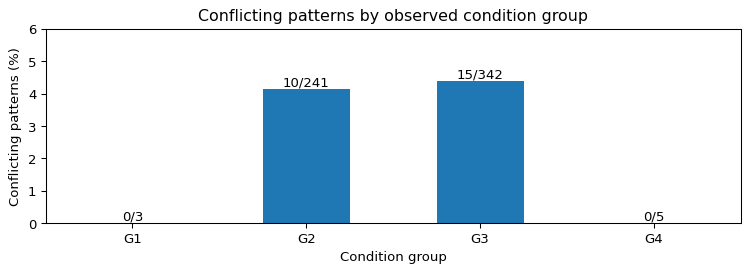

In [22]:
structure_conflicts=structure_patterns.groupby('condition_group').agg(
    patterns=('conflicting','size'),conflicting_patterns=('conflicting','sum'))
structure_conflicts['normal_only_patterns']=structure_conflicts.patterns-structure_conflicts.conflicting_patterns
structure_conflicts['conflicting_pattern_fraction']=structure_conflicts.conflicting_patterns/structure_conflicts.patterns
structure_conflicts['original_rows']=2*structure_conflicts.patterns
structure_conflicts['defect_rows']=structure_conflicts.conflicting_patterns
structure_conflicts['observed_defect_fraction']=structure_conflicts.defect_rows/structure_conflicts.original_rows
display(structure_conflicts.round(4))
fig,ax=plt.subplots(figsize=(8,3))
(100*structure_conflicts.conflicting_pattern_fraction).plot.bar(ax=ax,rot=0)
ax.set(title='Conflicting patterns by observed condition group',ylabel='Conflicting patterns (%)',xlabel='Condition group')
for i,(_,r) in enumerate(structure_conflicts.iterrows()):
    ax.text(i,100*r.conflicting_pattern_fraction+.1,f'{int(r.conflicting_patterns)}/{int(r.patterns)}',ha='center')
ax.set_ylim(0,6);plt.tight_layout();plt.show()

**결과와 해석:** G2는 10/241개 패턴(4.15%), G3는 15/342개 패턴(4.39%)이 충돌한다. 원본 불량 비율로는 각각 10/482행(2.07%), 15/684행(2.19%)이다. 공정값 중앙값의 차이와 달리 두 주요 조건군의 충돌 비율은 비슷하다. 이 조건군 구분 자체로 불량이 집중되는 집단을 설명하기는 어렵다.

G1·G4의 충돌은 0개지만 분모가 3개·5개 패턴이므로 안전한 조건이라는 근거는 아니다. **판단:** 조건군은 해석용으로 유지하되 조건군별 라벨 변경이나 정상 확정 규칙을 만들지 않는다. 다음에는 기존 집중 구간의 경향이 조건군 안에서도 나타나는지 확인한다.

## 3.6 기존 집중 구간은 조건군 안에서도 유지되는가?

기존에 관측한 `Barrel_Temperature_5 > 양품 중앙값` 및 `Max_Injection_Speed > 양품 중앙값`을 그대로 사용한다. 조건군마다 경계를 다시 최적화하지 않는다. 동일한 구간을 G2·G3 안팎으로 나눠 조건군의 구성 비율만으로 기존 집중이 설명되는지 살펴본다.

patterns  ...  observed_defect_fraction
condition_group focus_region            ...                          
G1              False                3  ...                  0.000000
                True                 0  ...                       NaN
G2              False              146  ...                  0.010274
                True                95  ...                  0.036842
G3              False              328  ...                  0.019817
                True                14  ...                  0.071429
G4              False                5  ...                  0.000000
                True                 0  ...                       NaN

[8 rows x 6 columns]

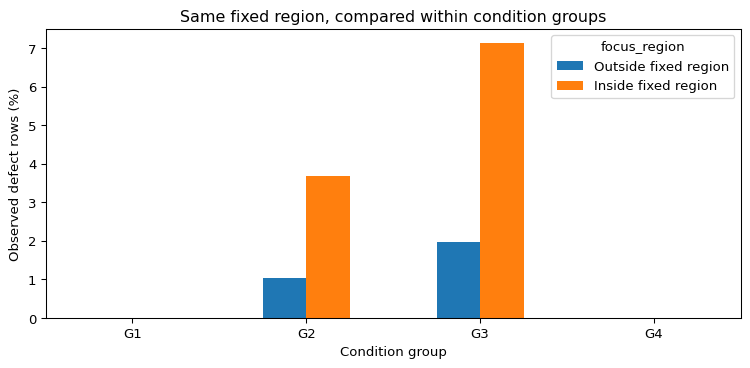

In [23]:
structure_normal=audit_labeled.loc[audit_y.eq(0)]
structure_barrel_cut=structure_normal.Barrel_Temperature_5.median()
structure_speed_cut=structure_normal.Max_Injection_Speed.median()
structure_patterns['focus_region']=(structure_patterns.Barrel_Temperature_5.gt(structure_barrel_cut)&
                                     structure_patterns.Max_Injection_Speed.gt(structure_speed_cut))
structure_full_index=pd.MultiIndex.from_product([structure_groups.index,[False,True]],names=['condition_group','focus_region'])
structure_region=structure_patterns.groupby(['condition_group','focus_region']).conflicting.agg(
    patterns='size',conflicting_patterns='sum').reindex(structure_full_index,fill_value=0)
structure_region['original_rows']=2*structure_region.patterns
structure_region['defect_rows']=structure_region.conflicting_patterns
structure_region['normal_rows']=structure_region.original_rows-structure_region.defect_rows
structure_region['observed_defect_fraction']=structure_region.defect_rows/structure_region.original_rows.replace(0,np.nan)
display(structure_region)
structure_inside=structure_region.xs(True,level='focus_region')
assert structure_inside.original_rows.sum()==218 and structure_inside.defect_rows.sum()==9
fig,ax=plt.subplots(figsize=(8,4))
(100*structure_region.observed_defect_fraction.unstack()).rename(columns={False:'Outside fixed region',True:'Inside fixed region'}).plot.bar(ax=ax,rot=0)
ax.set(title='Same fixed region, compared within condition groups',ylabel='Observed defect rows (%)',xlabel='Condition group')
plt.tight_layout();plt.show()

**결과와 해석:** G2에서는 구간 안이 7/190행(3.68%), 밖이 3/292행(1.03%)이다. G3에서도 안이 2/28행(7.14%), 밖이 13/656행(1.98%)이다. 두 주요 조건군 모두 안쪽의 관측 불량 비율이 높으므로, 전체 9/218행(4.13%)이라는 관측을 조건군 혼합만으로 설명할 수는 없다.

그러나 G3의 안쪽은 14개 패턴·불량 2행뿐이다. G2는 95/241개 패턴이 구간 안에 있지만 G3는 14/342개로, 구간이 포함하는 조건군의 비중도 크게 다르다. G1·G4에는 해당 구간 관측이 없어 빈 칸을 0%로 해석하지 않는다.

**판단:** 배럴 온도 5·최대 사출 속도의 동시 조건은 계속 확인할 관측 가설로 남긴다. 동일 데이터에서 발견한 구간을 다시 나눠 본 사후 탐색이므로 독립 재현이나 인과 검증은 아니다. 구간 밖 불량 16행이 있고 안에 양품 209행이 있으므로 라벨 교정·행 삭제·확정 판정 기준으로 사용하지 않는다.

## 3.7 동일 입력의 짝을 제외한 주변 조건의 구성

**질문:** 충돌 패턴 주변에도 충돌 패턴이 모이는가? 591개 고유 조건만 사용해 동일 입력의 양품 짝을 제거한 상태로 비교한다. 거리 비교는 각 조건군 안에서 수행한다.

공정값을 전체 고유 패턴에서 평균 순위 백분율로 바꿔 큰 수치 간격의 영향을 줄이고, 순위 좌표의 유클리드 거리를 계산한다. 상수열을 제외한 23개 변수와, 절대 Spearman 상관 0.9 이상일 때 원본 열 순서상 앞선 변수 하나만 남긴 거리용 21개 변수 결과를 비교한다. 이는 거리 정의의 민감도 확인이며 원본 입력 삭제가 아니다.

이웃 수 5·10·20과 동률인 경계 이웃을 모두 포함한다. 자기 자신은 제외하고 작은 조건군은 가능한 이웃만 사용한다. 비교 기준으로 조건군별 충돌 개수를 보존한 채 위치를 2,000회 무작위 재배치한다(시드 42). 재배치는 관측 위치의 집중 정도를 설명하는 참고 분포이며, 결과로 원본 라벨을 변경하지 않는다. 분류기나 예측 모델은 사용하지 않는다.

,excluded_from_alternative_distance,retained,abs_spearman
0,Average_Back_Pressure,Max_Back_Pressure,0.944221
1,Mold_Temperature_4,Mold_Temperature_3,0.987014


,distance,requested_neighbors,distance_features,observed_conflict_neighbor_fraction,randomized_mean,randomized_q025,randomized_q975
0,all_nonconstant,5,23,0.056,0.0393,0.000,0.0880
1,all_nonconstant,10,23,0.056,0.0393,0.012,0.0721
2,all_nonconstant,20,23,0.048,0.0395,0.020,0.0640
3,correlation_reduced,5,21,0.056,0.0398,0.008,0.0880
4,correlation_reduced,10,21,0.064,0.0394,0.012,0.0720
5,correlation_reduced,20,21,0.056,0.0395,0.020,0.0640


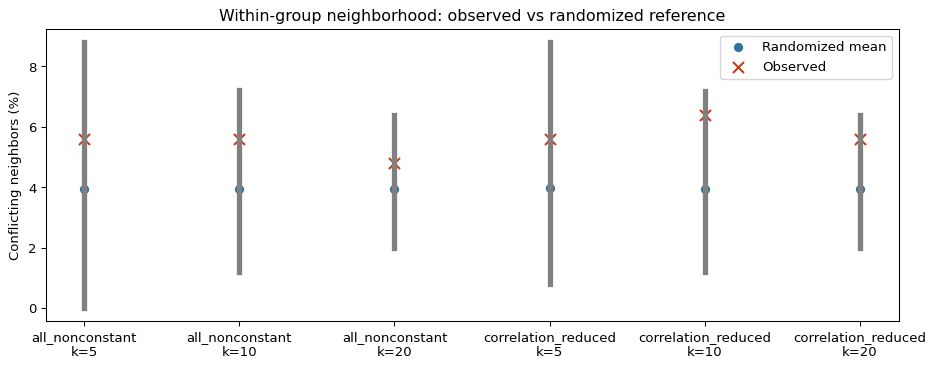

In [24]:
structure_distance_columns=[c for c in audit_features if structure_patterns[c].nunique()>1]
structure_abs_corr=structure_patterns[structure_distance_columns].corr(method='spearman').abs()
structure_reduced=[];structure_redundant=[]
for c in structure_distance_columns:
    similar=[other for other in structure_reduced if structure_abs_corr.loc[c,other]>=.9]
    if similar:structure_redundant.append([c,similar[0],structure_abs_corr.loc[c,similar[0]]])
    else:structure_reduced.append(c)
structure_distance_redundancy=pd.DataFrame(structure_redundant,columns=['excluded_from_alternative_distance','retained','abs_spearman'])
display(structure_distance_redundancy)
structure_flags=structure_patterns.conflicting.to_numpy()
structure_group_array=structure_patterns.condition_group.to_numpy()
structure_rng=np.random.default_rng(42)
structure_permutations=np.tile(structure_flags,(2000,1)).astype(float)
for label in structure_groups.index:
    ids=np.flatnonzero(structure_group_array==label)
    for b in range(len(structure_permutations)):
        structure_permutations[b,ids]=structure_rng.permutation(structure_flags[ids])
structure_neighbor_rows=[];structure_neighbor_cases=[]
for distance_name,columns in [('all_nonconstant',structure_distance_columns),('correlation_reduced',structure_reduced)]:
    ranked=structure_patterns[columns].rank(method='average',pct=True).to_numpy()
    distances=cdist(ranked,ranked)/np.sqrt(len(columns))
    np.fill_diagonal(distances,np.inf)
    distances[structure_group_array[:,None]!=structure_group_array[None,:]]=np.inf
    for k in [5,10,20]:
        effective_k=np.minimum(k,np.isfinite(distances).sum(axis=1))
        assert (effective_k>0).all()
        boundary=np.array([np.partition(row,int(kk)-1)[int(kk)-1] for row,kk in zip(distances,effective_k)])
        adjacency=(distances<=boundary[:,None]+1e-12)&np.isfinite(distances)
        assert not np.diag(adjacency).any()
        weights=csr_matrix(adjacency/adjacency.sum(axis=1)[:,None])
        neighbor_fraction=weights@structure_flags
        observed=float(neighbor_fraction[structure_flags==1].mean())
        randomized=np.sum((weights@structure_permutations.T)*structure_permutations.T,axis=0)/structure_flags.sum()
        structure_neighbor_rows.append([distance_name,k,len(columns),observed,float(randomized.mean()),
            float(np.quantile(randomized,.025)),float(np.quantile(randomized,.975))])
        for pos in np.flatnonzero(structure_flags==1):
            structure_neighbor_cases.append([distance_name,k,int(structure_patterns.index[pos]),
                structure_group_array[pos],int(adjacency[pos].sum()),float(neighbor_fraction[pos])])
structure_neighbor_summary=pd.DataFrame(structure_neighbor_rows,columns=[
    'distance','requested_neighbors','distance_features','observed_conflict_neighbor_fraction',
    'randomized_mean','randomized_q025','randomized_q975'])
structure_neighbor_detail=pd.DataFrame(structure_neighbor_cases,columns=[
    'distance','requested_neighbors','pattern_id','condition_group','actual_neighbors','conflict_neighbor_fraction'])
display(structure_neighbor_summary.round(4))
fig,ax=plt.subplots(figsize=(10,4))
for i,r in structure_neighbor_summary.iterrows():
    ax.plot([i,i],[100*r.randomized_q025,100*r.randomized_q975],color='gray',linewidth=4)
    ax.scatter(i,100*r.randomized_mean,color='#3274A1',label='Randomized mean' if i==0 else None)
    ax.scatter(i,100*r.observed_conflict_neighbor_fraction,color='#CC3311',marker='x',s=70,label='Observed' if i==0 else None)
ax.set_xticks(range(len(structure_neighbor_summary)),[
    f'{r.distance}\nk={r.requested_neighbors}' for r in structure_neighbor_summary.itertuples()])
ax.set(ylabel='Conflicting neighbors (%)',title='Within-group neighborhood: observed vs randomized reference')
ax.legend();plt.tight_layout();plt.show()

**결과와 해석:** 대체 거리에서 제외한 변수는 평균 배압(최대 배압과 상관 0.944)과 금형 온도 4(온도 3과 0.987)이다. 원본 저장 데이터의 열은 그대로 유지한다.

충돌 조건의 이웃 10개를 볼 때 주변 충돌 비율은 23개 변수 거리에서 5.6%, 중복 정보를 줄인 21개 변수 거리에서 6.4%다. 같은 조건군 안에서 충돌 개수를 유지한 무작위 재배치 평균은 약 3.9%, 중앙 95% 참고 범위는 각각 1.2~7.2%다. 5·10·20개 이웃과 두 거리 정의의 관측값 모두 각 참고 범위 안에 있다.

**판단:** 일부 가까운 충돌이 있지만, 이번 거리 정의와 조건군 내 비교에서 뚜렷한 별도 충돌 군집을 확인했다고 보기 어렵다. 이는 군집이 없다는 증명이 아니다. 충돌 25개가 적고 거리의 정의에도 의존하므로, 주변 양품을 불량으로 바꾸거나 국소 이상값으로 삭제하는 근거로 쓰지 않는다. 참고 범위는 관측값의 신뢰구간이나 여러 탐색을 보정한 검정 결과가 아니다.

## 3.8 충전시간을 중심으로 비라벨 적용 범위 분해

**질문:** 비라벨의 51.24% 범위 이탈 중 충전시간이 얼마나 기여하는가? 라벨의 두 충전시간 값에 대한 위치를 하한 미만·관측값 일치·두 값 사이·상한 초과로 나누고, 다른 비상수 변수의 범위 이탈과 교차한다. 일치 허용오차는 표준화 좌표에서 절대 1e-10으로 고정한다.

이 구분을 생산 모드로 해석하거나 비라벨을 가까운 라벨 값으로 강제 대응시키지 않는다. 서로 다른 파일의 제공 좌표계 비교이며 실제 물리 단위의 범위 차이는 별도 확인이 필요하다.

,other_variables_within_range,other_variable_outside
filling_location,,
below,0,2
on_observed,0,0
between,17525,5267
above,8986,4161


,range_category,rows,fraction
0,Filling only,8986,0.250021
1,Filling and other,4163,0.115829
2,Other only,5267,0.146546
3,Within all nonconstant ranges,17525,0.487605


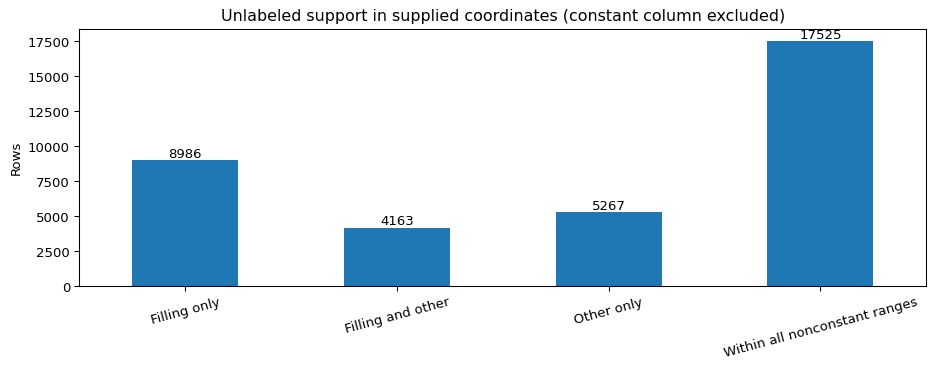

In [25]:
structure_fill_low=audit_X.Filling_Time.min();structure_fill_high=audit_X.Filling_Time.max()
structure_unlabeled_fill=audit_U.Filling_Time
structure_on_observed=(np.isclose(structure_unlabeled_fill,structure_fill_low,atol=1e-10,rtol=0)|
                       np.isclose(structure_unlabeled_fill,structure_fill_high,atol=1e-10,rtol=0))
structure_fill_category=np.select([structure_on_observed,structure_unlabeled_fill.lt(structure_fill_low),
                                  structure_unlabeled_fill.gt(structure_fill_high)],
                                 ['on_observed','below','above'],default='between')
structure_other_columns=[c for c in audit_active if c!='Filling_Time']
structure_other_outside=(audit_U[structure_other_columns].lt(audit_X[structure_other_columns].min())|
                         audit_U[structure_other_columns].gt(audit_X[structure_other_columns].max())).any(axis=1)
structure_coverage_cross=pd.crosstab(pd.Series(structure_fill_category,name='filling_location'),
    structure_other_outside.rename('other_variable_outside')).reindex(
        index=['below','on_observed','between','above'],columns=[False,True],fill_value=0)
structure_coverage_cross.columns=['other_variables_within_range','other_variable_outside']
display(structure_coverage_cross)
structure_fill_outside=structure_unlabeled_fill.lt(structure_fill_low)|structure_unlabeled_fill.gt(structure_fill_high)
structure_coverage_parts=pd.DataFrame([
    ['Filling only',int((structure_fill_outside & ~structure_other_outside).sum())],
    ['Filling and other',int((structure_fill_outside & structure_other_outside).sum())],
    ['Other only',int((~structure_fill_outside & structure_other_outside).sum())],
    ['Within all nonconstant ranges',int((~structure_fill_outside & ~structure_other_outside).sum())],
],columns=['range_category','rows'])
structure_coverage_parts['fraction']=structure_coverage_parts.rows/len(audit_U)
display(structure_coverage_parts)
assert structure_coverage_parts.rows.sum()==len(audit_U)
assert structure_coverage_parts.iloc[:3].rows.sum()==int(audit_outside_rows.sum())
fig,ax=plt.subplots(figsize=(10,4))
structure_coverage_parts.set_index('range_category').rows.plot.bar(ax=ax,rot=15)
for container in ax.containers:ax.bar_label(container)
ax.set(title='Unlabeled support in supplied coordinates (constant column excluded)',ylabel='Rows',xlabel='')
plt.tight_layout();plt.show()

**결과와 판단:** 충전시간이 두 관측값 사이에 있는 비라벨 행은 **22,792행(63.42%)**, 상한 초과는 **13,147행**, 하한 미만은 **2행**이다. 허용오차 내 두 관측값과 일치하는 행은 0개다. 충전시간만 보면 범위 안에 있는 행도 라벨 데이터에서 직접 관측된 값은 아니다.

비상수 변수의 범위 밖 18,416행은 **충전시간만 이탈 8,986행**, **충전시간과 다른 변수 동시 이탈 4,163행**, **다른 변수만 이탈 5,267행**으로 나뉜다. 따라서 기존 51.24%를 여러 변수의 전반적 이탈로만 설명하면 안 된다. 반대로 충전시간 하나의 문제로 모두 설명할 수도 없다.

**처리 결정:** 비라벨 값을 두 라벨 값으로 반올림하거나 조건군에 강제 배정하지 않는다. 라벨의 희소한 값과 비라벨의 중간값·외부값 구조를 범위 점검표에 남긴다. 각 파일의 정규화 기준이 확인되기 전까지 중간값을 물리적 보간, 범위 밖을 실제 공정 이상이라고 부르지 않는다.

In [26]:
structure_output_dir=audit_root/'output/rg3_structure_eda'
structure_output_dir.mkdir(parents=True,exist_ok=True)
structure_tables={
    'condition_groups.csv':structure_groups.reset_index(),
    'condition_medians.csv':structure_medians.reset_index(),
    'conflicts_by_condition.csv':structure_conflicts.reset_index(),
    'fixed_region_by_condition.csv':structure_region.reset_index(),
    'distance_redundancy.csv':structure_distance_redundancy,
    'neighborhood_summary.csv':structure_neighbor_summary,
    'neighborhood_cases.csv':structure_neighbor_detail,
    'filling_coverage_cross.csv':structure_coverage_cross.reset_index(),
    'coverage_components.csv':structure_coverage_parts,
}
for name,table in structure_tables.items():table.to_csv(structure_output_dir/name,index=False,encoding='utf-8')
structure_config={
    'scope':'Descriptive EDA only; no predictive model or source-label modification.',
    'condition_features':structure_keys,'unit':'Unique full-input pattern except row coverage tables',
    'fixed_region':{'Barrel_Temperature_5_gt':float(structure_barrel_cut),'Max_Injection_Speed_gt':float(structure_speed_cut)},
    'neighbors':[5,10,20],'neighbor_scope':'Within condition group, self excluded, boundary ties included',
    'distance':'Euclidean on global average percentile ranks, divided by sqrt(feature count)',
    'alternative_distance_features':structure_reduced,
    'randomization':{'seed':42,'repetitions':2000,'preserve':'Conflict counts within each condition group'},
    'coordinate_equality_atol':1e-10,
}
(structure_output_dir/'eda_config.json').write_text(json.dumps(structure_config,indent=2)+'\n',encoding='utf-8')
print('추가 EDA 표와 설정 저장:',structure_output_dir)

추가 EDA 표와 설정 저장: C:\SeokHwanHong-github-blog\26KAMP\output\rg3_structure_eda


## 3.9 세 가지 비지도 군집화 비교

**질문:** 공정값만으로 만든 군집에서 양품 전용·충돌 패턴이 다르게 분포하는가? **계층적 군집화(Ward) → K-Medoids → K-Means** 순서로 적용한다. 분류기 학습이나 예측 성능 평가가 아니라 공정조건의 구조를 확인하는 EDA다.

원본 1,182행을 591개 고유 전체입력 패턴으로 표현한 뒤 군집 번호를 원본 행에 다시 연결한다. 라벨·충돌 여부·ID·행 순서·기존 조건군은 군집 입력에서 제외한다. 군집화 후에만 라벨과 기존 G1~G4의 구성을 비교한다.

**공통 기준:** 주 분석은 상수열을 제외한 제공 표준화 값 23개와 유클리드 거리다. 군집 수 후보는 2~6개이며 세 방법의 실루엣 평균이 가장 높은 공통 군집 수를 선택한다. 불량 집중도를 이용해 군집 수를 고르지 않는다. 추가로 23개 변수의 순위 좌표, 상관 중복을 줄인 21개 변수의 순위 좌표를 비교한다. 원본 저장 열과 라벨은 변경하지 않는다.

K-Medoids는 전용 외부 패키지 대신 군집 내 거리합을 최소화하는 관측점으로 대표점을 반복 갱신하는 **alternate 방식**을 명시적으로 구현한다. 5회 초기화 중 거리합이 작은 결과를 사용하며, 전역 최적해나 PAM의 전체 교환 최적화를 보장하지 않는다. K-Means는 20회 초기화, 시드는 42다.

,representation,k,method,silhouette,smallest_cluster,largest_cluster
0,supplied_23,2,Ward,0.1881,221,370
1,supplied_23,2,KMedoids,0.1965,229,362
2,supplied_23,2,KMeans,0.1991,273,318
3,supplied_23,3,Ward,0.1379,177,221
4,supplied_23,3,KMedoids,0.1482,112,309
5,supplied_23,3,KMeans,0.1444,175,241
6,supplied_23,4,Ward,0.1103,80,221
7,supplied_23,4,KMedoids,0.0978,119,192
8,supplied_23,4,KMeans,0.1239,104,192
9,supplied_23,5,Ward,0.1188,3,221


,representation,selected_common_k
0,rank_21,2
1,rank_23,2
2,supplied_23,2


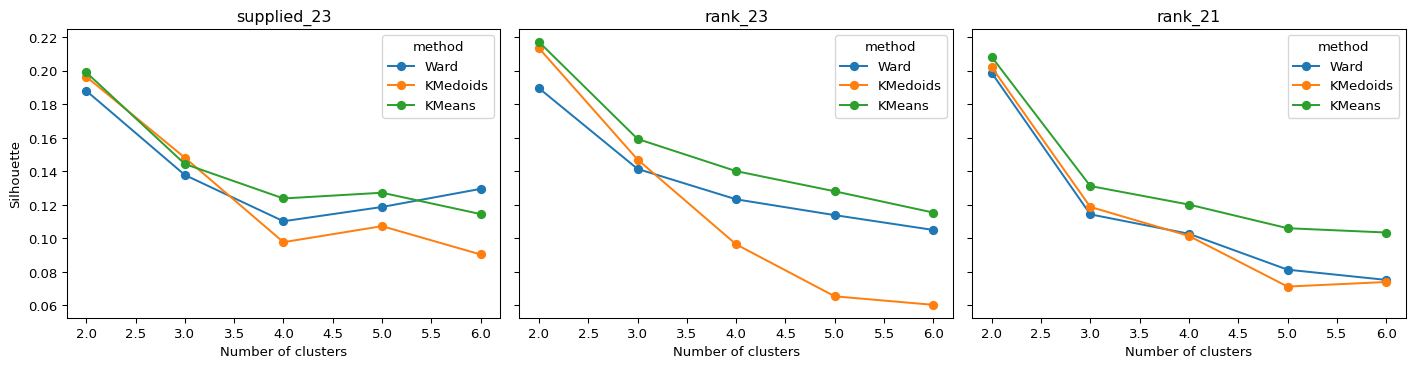

In [27]:
def medoids(D,k,seed=42,n_init=5,max_iter=100):
    best=None
    for restart in range(n_init):
        rng=np.random.default_rng(seed+restart)
        med=[int(rng.integers(len(D)))]
        while len(med)<k:
            nearest=D[:,med].min(axis=1)**2
            med.append(int(rng.choice(len(D),p=nearest/nearest.sum())))
        for step in range(max_iter):
            labels=D[:,med].argmin(axis=1)
            updated=[]
            for j in range(k):
                members=np.flatnonzero(labels==j)
                updated.append(int(members[np.argmin(D[np.ix_(members,members)].sum(axis=1))]))
            if updated==med:break
            med=updated
        labels=D[:,med].argmin(axis=1);cost=D[np.arange(len(D)),np.asarray(med)[labels]].sum()
        if best is None or cost<best[0]:best=(cost,labels,np.asarray(med),step+1)
    return best

# 작은 두 집단에서 대표점·목적함수가 정확히 계산되는지 확인한다.
cluster_toy=cdist(np.array([[0.],[1.],[2.],[10.],[11.],[12.]]),np.array([[0.],[1.],[2.],[10.],[11.],[12.]]))
cluster_toy_fit=medoids(cluster_toy,2)
assert np.isclose(cluster_toy_fit[0],4.)
assert set(cluster_toy_fit[2])=={1,4}

cluster_methods=['Ward','KMedoids','KMeans']
cluster_forms={
    'supplied_23':structure_patterns[structure_distance_columns].to_numpy(),
    'rank_23':structure_patterns[structure_distance_columns].rank(method='average',pct=True).to_numpy(),
    'rank_21':structure_patterns[structure_reduced].rank(method='average',pct=True).to_numpy(),
}
cluster_distances={};cluster_linkages={};cluster_assignments={};cluster_medoids={};cluster_candidate_rows=[]
with threadpool_limits(limits=1):
    for representation,values in cluster_forms.items():
        distances=cdist(values,values);np.fill_diagonal(distances,0)
        cluster_distances[representation]=distances
        cluster_linkages[representation]=linkage(values,method='ward')
        for k in range(2,7):
            ward_labels=cut_tree(cluster_linkages[representation],n_clusters=k).ravel()
            medoid_fit=medoids(distances,k,seed=42,n_init=5)
            km=KMeans(n_clusters=k,n_init=20,random_state=42).fit(values)
            assignments={'Ward':ward_labels,'KMedoids':medoid_fit[1],'KMeans':km.labels_}
            cluster_medoids[(representation,k)]=medoid_fit[2]
            for method,labels in assignments.items():
                assert len(np.unique(labels))==k
                cluster_assignments[(representation,k,method)]=labels
                counts=np.bincount(labels)
                cluster_candidate_rows.append([representation,k,method,
                    silhouette_score(distances,labels,metric='precomputed'),int(counts.min()),int(counts.max())])
cluster_candidates=pd.DataFrame(cluster_candidate_rows,columns=[
    'representation','k','method','silhouette','smallest_cluster','largest_cluster'])
cluster_selected_k={name:int(g.groupby('k').silhouette.mean().idxmax())
                     for name,g in cluster_candidates.groupby('representation')}
display(cluster_candidates.round(4))
display(pd.DataFrame(cluster_selected_k.items(),columns=['representation','selected_common_k']))
fig,axes=plt.subplots(1,3,figsize=(15,4),sharey=True)
for ax,(name,g) in zip(axes,cluster_candidates.groupby('representation',sort=False)):
    g.pivot(index='k',columns='method',values='silhouette')[cluster_methods].plot(marker='o',ax=ax)
    ax.set(title=name,ylabel='Silhouette',xlabel='Number of clusters')
plt.tight_layout();plt.show()

**군집 수 비교 해석:** 주 분석에서 k=2의 실루엣은 Ward 0.188, K-Medoids 0.197, K-Means 0.199다. 세 방법 각각에서도 후보 2~6 중 2가 가장 높고, 두 순위 표현에서도 공통 선택은 2다. 여기서 2는 정상·불량 두 라벨을 맞추기 위해 정한 값이 아니다.

점수가 약 0.2이므로 군집 수를 더 늘리는 것보다 상대적으로 낫다는 결과와 군집 경계가 뚜렷하다는 주장은 구분한다. 원본 표현의 k=5에서는 3개 또는 5개짜리 작은 군집도 나타나므로 작은 군집을 불량 집단이라고 해석하지 않는다. 아래에서 같은 k=2를 기준으로 구성을 비교한다.

### 3.9.1 계층적 군집화: 큰 공정조건의 분기 확인

Ward는 병합에 따른 군집 내 제곱거리 증가를 기준으로 계층을 만든다. 덴드로그램은 마지막 12개 병합 단위만 표시하고, 세 방법의 비교는 공통 k를 사용한다. 군집 번호 자체는 임의의 이름이다.

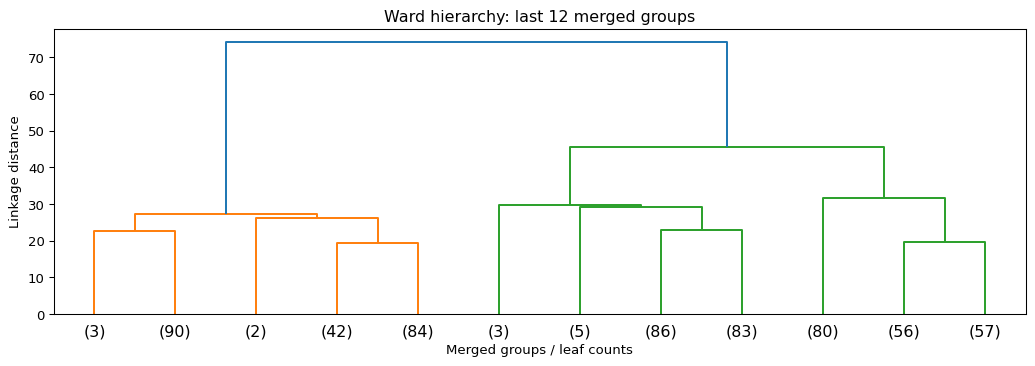

,cluster,patterns,conflicting_patterns,normal_only_patterns,conflicting_pattern_fraction,original_rows,defect_rows,normal_rows,original_defect_fraction,representation,method
0,0,221,11,210,0.049774,442,11,431,0.024887,supplied_23,Ward
1,1,370,14,356,0.037838,740,14,726,0.018919,supplied_23,Ward


condition_group,cluster,G1,G2,G3,G4,representation,method
0,0,3,213,5,0,supplied_23,Ward
1,1,0,28,337,5,supplied_23,Ward


In [28]:
cluster_primary='supplied_23'
cluster_k=cluster_selected_k[cluster_primary]
fig,ax=plt.subplots(figsize=(11,4))
dendrogram(cluster_linkages[cluster_primary],truncate_mode='lastp',p=12,show_leaf_counts=True,ax=ax)
ax.set(title='Ward hierarchy: last 12 merged groups',ylabel='Linkage distance',xlabel='Merged groups / leaf counts')
plt.tight_layout();plt.show()
cluster_row_summaries=[];cluster_group_tables=[];cluster_profile_tables=[];cluster_pattern_tables=[]
for representation in cluster_forms:
    k=cluster_selected_k[representation]
    for method in cluster_methods:
        labels=cluster_assignments[(representation,k,method)]
        table=structure_patterns.copy()
        table['cluster']=labels
        summary=table.groupby('cluster').conflicting.agg(patterns='size',conflicting_patterns='sum')
        summary['normal_only_patterns']=summary.patterns-summary.conflicting_patterns
        summary['conflicting_pattern_fraction']=summary.conflicting_patterns/summary.patterns
        summary['original_rows']=2*summary.patterns
        summary['defect_rows']=summary.conflicting_patterns
        summary['normal_rows']=summary.original_rows-summary.defect_rows
        summary['original_defect_fraction']=summary.defect_rows/summary.original_rows
        summary['representation']=representation;summary['method']=method
        cluster_row_summaries.append(summary.reset_index())
        cross=pd.crosstab(table.cluster,table.condition_group).reset_index()
        cross['representation']=representation;cross['method']=method;cluster_group_tables.append(cross)
        profiles=table.groupby('cluster')[audit_features].median().reset_index()
        profiles['representation']=representation;profiles['method']=method;cluster_profile_tables.append(profiles)
        patterns=pd.DataFrame({'pattern_id':structure_patterns.index,'cluster':labels,
            'representation':representation,'method':method})
        cluster_pattern_tables.append(patterns)
cluster_summary=pd.concat(cluster_row_summaries,ignore_index=True)
cluster_condition_cross=pd.concat(cluster_group_tables,ignore_index=True).fillna(0)
cluster_profiles=pd.concat(cluster_profile_tables,ignore_index=True)
cluster_pattern_assignments=pd.concat(cluster_pattern_tables,ignore_index=True)
display(cluster_summary.query("representation == 'supplied_23' and method == 'Ward'"))
display(cluster_condition_cross.query("representation == 'supplied_23' and method == 'Ward'"))

**Ward 해석:** 두 군집은 221개·370개 패턴이고 충돌 패턴은 11개·14개다. 패턴 기준 충돌 비율은 4.98%·3.78%이며 두 군집 모두 양품 전용과 충돌 조건을 포함한다. 원본 행의 불량 비율은 이 비율의 절반이므로 혼동하지 않는다. 계층이 존재한다는 것만으로 정상·불량의 경계를 찾았다고 볼 수 없다.

### 3.9.2 K-Medoids: 실제 관측 대표조건으로 비교

대표점은 실제 관측된 전체입력 패턴이다. 대표 ID와 공정값은 군집을 설명하는 자료이며, 그 ID나 라벨을 거리 계산에 사용하지 않는다.

In [29]:
cluster_medoid_positions=cluster_medoids[(cluster_primary,cluster_k)]
cluster_representatives=structure_patterns.iloc[cluster_medoid_positions][audit_features].copy()
cluster_representatives.insert(0,'cluster',np.arange(cluster_k))
cluster_representatives.insert(1,'representative_source_id',[
    audit_patterns.loc[pid,'source_ids'][0] for pid in cluster_representatives.index])
cluster_representatives=cluster_representatives.reset_index()
display(cluster_representatives)
display(cluster_summary.query("representation == 'supplied_23' and method == 'KMedoids'"))
display(cluster_condition_cross.query("representation == 'supplied_23' and method == 'KMedoids'"))

,pattern_id,cluster,representative_source_id,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,Max_Screw_RPM,Average_Screw_RPM,Max_Injection_Pressure,Max_Switch_Over_Pressure,Max_Back_Pressure,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
0,476,0,2163,-0.029099,0.838552,-0.715956,0.249511,-1.806725,-1.114437,0.588367,0.0,-0.952293,0.677109,-0.421798,1.203938,0.916128,0.847522,1.018118,0.096629,0.957919,-0.002081,0.047749,-0.344258,0.143005,-0.528528,1.171203,1.337365
1,173,1,1557,-0.029099,-1.192531,0.855360,0.249511,1.033078,0.480326,-0.974521,0.0,0.617645,0.677109,-0.421798,-0.108802,-0.554587,-0.708027,-0.144380,0.096629,-0.011452,0.612574,-0.829743,0.282727,-0.354184,-0.223487,0.031342,-0.240729


,cluster,patterns,conflicting_patterns,normal_only_patterns,conflicting_pattern_fraction,original_rows,defect_rows,normal_rows,original_defect_fraction,representation,method
2,0,229,10,219,0.043668,458,10,448,0.021834,supplied_23,KMedoids
3,1,362,15,347,0.041436,724,15,709,0.020718,supplied_23,KMedoids


condition_group,cluster,G1,G2,G3,G4,representation,method
2,0,0,6,218,5,supplied_23,KMedoids
3,1,3,235,124,0,supplied_23,KMedoids


**K-Medoids 해석:** 두 군집은 229개·362개 패턴이고 충돌은 10개·15개로, 충돌 비율이 4.37%·4.14%다. 공정조건을 두 대표점으로 요약할 수 있지만 라벨 구성의 차이는 작다. 실제 대표조건을 보여줄 수 있다는 장점과 불량 집중을 설명하는 능력은 별개다. 대표점 교대 갱신의 국소해에 의존하므로 이후 표본 변화에 대한 민감도도 확인한다.

### 3.9.3 K-Means: 평균 중심과 공통 시각화

세 방법을 같은 PCA 2차원 좌표에 표시한다. PCA는 그림의 축을 만들기 위한 용도이며 군집은 전체 23개 좌표에서 계산했다. 주황색 빈 원은 충돌 패턴 위치로, 그림을 만들 때 사후에 표시한다.

,cluster,patterns,conflicting_patterns,normal_only_patterns,conflicting_pattern_fraction,original_rows,defect_rows,normal_rows,original_defect_fraction,representation,method
4,0,273,14,259,0.051282,546,14,532,0.025641,supplied_23,KMeans
5,1,318,11,307,0.034591,636,11,625,0.017296,supplied_23,KMeans


condition_group,cluster,G1,G2,G3,G4,representation,method
4,0,3,225,45,0,supplied_23,KMeans
5,1,0,16,297,5,supplied_23,KMeans


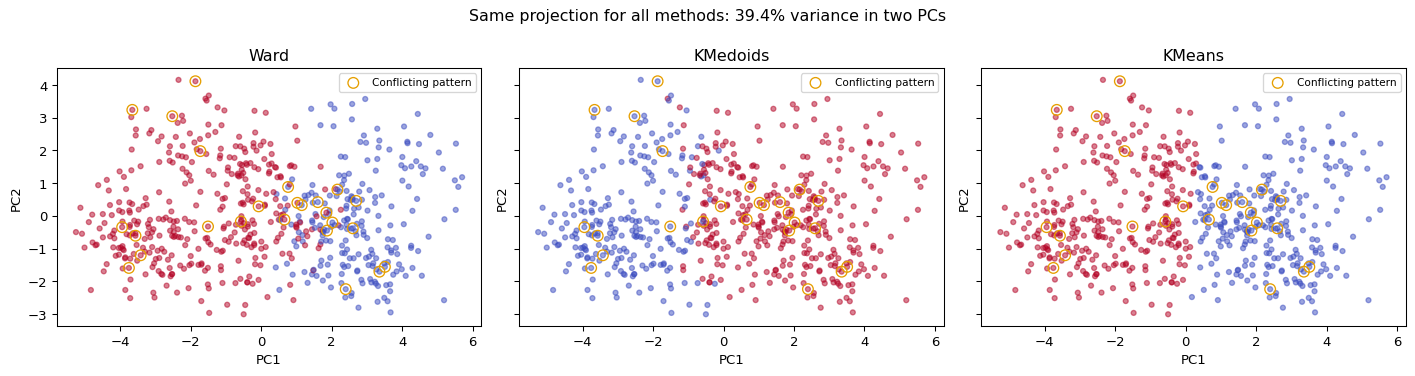

In [30]:
display(cluster_summary.query("representation == 'supplied_23' and method == 'KMeans'"))
display(cluster_condition_cross.query("representation == 'supplied_23' and method == 'KMeans'"))
cluster_pca=PCA(n_components=2)
cluster_coordinates=cluster_pca.fit_transform(cluster_forms[cluster_primary])
fig,axes=plt.subplots(1,3,figsize=(15,4),sharex=True,sharey=True)
for ax,method in zip(axes,cluster_methods):
    labels=cluster_assignments[(cluster_primary,cluster_k,method)]
    ax.scatter(cluster_coordinates[:,0],cluster_coordinates[:,1],c=labels,cmap='coolwarm',s=14,alpha=.5)
    mask=structure_patterns.conflicting.eq(1).to_numpy()
    ax.scatter(cluster_coordinates[mask,0],cluster_coordinates[mask,1],facecolors='none',edgecolors='#E69F00',s=65,label='Conflicting pattern')
    ax.set(title=method,xlabel='PC1',ylabel='PC2');ax.legend(fontsize=8)
fig.suptitle(f'Same projection for all methods: {cluster_pca.explained_variance_ratio_.sum():.1%} variance in two PCs')
plt.tight_layout();plt.show()

**K-Means 해석:** 두 군집은 273개·318개 패턴, 충돌은 14개·11개로 비율은 5.13%·3.46%다. 세 방법 중 주 분석에서 군집 간 충돌 비율 차이는 더 크지만, 라벨을 보고 이 방법을 우수하다고 선택하지 않는다. PCA 그림에서 보이는 겹침은 전체 공간의 군집 품질과 동일하지 않으며, 2차원에서 떨어져 보이는 점을 불량으로 단정하지 않는다.

### 3.9.4 방법·입력 표현·부분표본에 따른 일관성

방법 간 군집 일치는 ARI로 비교한다. 여기서 ARI는 **군집 번호끼리**의 일치도이며 정상·불량에 대한 정확도가 아니다. 값이 1이면 같은 분할이고, 0 부근이면 우연 일치 수준이다.

주 분석에서 무작위 80% 패턴을 비복원 추출해 10회 재군집화하고, 전체 자료의 군집 중 해당 부분과 얼마나 일치하는지 확인한다. 군집 수와 입력 좌표를 고정하며, 이 수치는 표본 변화 민감도이지 독립 검증 성능이 아니다.

In [31]:
cluster_agreement=[];cluster_representation_agreement=[]
for representation in cluster_forms:
    k=cluster_selected_k[representation]
    for left,right in combinations(cluster_methods,2):
        cluster_agreement.append([representation,left,right,adjusted_rand_score(
            cluster_assignments[(representation,k,left)],cluster_assignments[(representation,k,right)])])
for method in cluster_methods:
    for alternative in ['rank_23','rank_21']:
        cluster_representation_agreement.append([method,alternative,adjusted_rand_score(
            cluster_assignments[(cluster_primary,cluster_k,method)],
            cluster_assignments[(alternative,cluster_selected_k[alternative],method)])])
cluster_agreement=pd.DataFrame(cluster_agreement,columns=['representation','method_1','method_2','ARI'])
cluster_representation_agreement=pd.DataFrame(cluster_representation_agreement,columns=['method','alternative_representation','ARI_vs_supplied'])
cluster_stability_rows=[]
with threadpool_limits(limits=1):
    for trial in range(10):
        rng=np.random.default_rng(100+trial)
        ids=np.sort(rng.choice(len(structure_patterns),size=int(.8*len(structure_patterns)),replace=False))
        values=cluster_forms[cluster_primary][ids]
        D=cluster_distances[cluster_primary][np.ix_(ids,ids)]
        trial_labels={
            'Ward':cut_tree(linkage(values,method='ward'),n_clusters=cluster_k).ravel(),
            'KMedoids':medoids(D,cluster_k,seed=42,n_init=5)[1],
            'KMeans':KMeans(n_clusters=cluster_k,n_init=20,random_state=42).fit_predict(values),
        }
        for method,labels in trial_labels.items():
            cluster_stability_rows.append([method,trial,adjusted_rand_score(
                cluster_assignments[(cluster_primary,cluster_k,method)][ids],labels)])
cluster_stability=pd.DataFrame(cluster_stability_rows,columns=['method','trial','ARI_vs_full_subset'])
display(cluster_agreement.round(3));display(cluster_representation_agreement.round(3))
display(cluster_stability.groupby('method').ARI_vs_full_subset.agg(['mean','min','max']).round(3))
display(cluster_summary[['representation','method','cluster','patterns','conflicting_patterns','conflicting_pattern_fraction']].round(4))
display(cluster_profiles.query("representation == 'supplied_23'")[['method','cluster']+structure_context].round(3))

,representation,method_1,method_2,ARI
0,supplied_23,Ward,KMedoids,0.270
1,supplied_23,Ward,KMeans,0.678
2,supplied_23,KMedoids,KMeans,0.487
3,rank_23,Ward,KMedoids,0.311
4,rank_23,Ward,KMeans,0.587
5,rank_23,KMedoids,KMeans,0.618
6,rank_21,Ward,KMedoids,0.645
7,rank_21,Ward,KMeans,0.618
8,rank_21,KMedoids,KMeans,0.651


,method,alternative_representation,ARI_vs_supplied
0,Ward,rank_23,0.825
1,Ward,rank_21,0.502
2,KMedoids,rank_23,0.856
3,KMedoids,rank_21,0.777
4,KMeans,rank_23,0.907
5,KMeans,rank_21,0.914


,mean,min,max
method,,,
KMeans,0.984,0.917,1.000
KMedoids,0.660,0.464,1.000
Ward,0.912,0.760,0.958


,representation,method,cluster,patterns,conflicting_patterns,conflicting_pattern_fraction
0,supplied_23,Ward,0,221,11,0.0498
1,supplied_23,Ward,1,370,14,0.0378
2,supplied_23,KMedoids,0,229,10,0.0437
3,supplied_23,KMedoids,1,362,15,0.0414
4,supplied_23,KMeans,0,273,14,0.0513
5,supplied_23,KMeans,1,318,11,0.0346
6,rank_23,Ward,0,218,10,0.0459
7,rank_23,Ward,1,373,15,0.0402
8,rank_23,KMedoids,0,348,15,0.0431
9,rank_23,KMedoids,1,243,10,0.0412


,method,cluster,Max_Injection_Speed,Max_Back_Pressure,Plasticizing_Time,Cushion_Position,Barrel_Temperature_5,Mold_Temperature_3
0,Ward,0,0.618,-0.708,0.406,0.480,-0.031,-0.254
1,Ward,1,-0.167,0.536,-0.491,-0.317,-0.031,0.530
2,KMedoids,0,-0.952,0.848,-0.716,-1.114,-0.031,1.029
3,KMedoids,1,0.618,-0.397,0.182,0.480,-0.031,-0.111
4,KMeans,0,0.618,-0.708,0.406,0.480,-0.031,-0.254
5,KMeans,1,-0.952,0.536,-0.491,-0.317,-0.031,0.886


**방법 간 비교:** 주 분석에서 Ward–K-Means의 ARI는 0.678, Ward–K-Medoids는 0.270, K-Medoids–K-Means는 0.487이다. 모두 k=2를 택해도 같은 경계로 나뉘지는 않는다. 군집 번호 0·1은 방법 간 같은 공정조건을 뜻하지 않으므로 교차표와 대표 공정값을 함께 읽는다.

원본 좌표에서 순위 좌표로 바꾸거나 상관 중복을 줄이면 배정도 달라진다. 따라서 한 번 얻은 군집 번호를 확정적인 생산 모드로 간주하지 않는다. 부분표본 ARI가 낮거나 변동이 큰 방법은 표본 구성에도 더 민감하다. 세 방법 모두 양쪽 군집에 충돌이 남으며, 21개 순위 좌표에서도 충돌 비율은 약 3.17~5.43% 범위로 나타난다.

**부분표본 비교 결과:** 80% 패턴을 10회 다시 추출했을 때 평균 ARI는 K-Means 0.984(최소 0.917), Ward 0.912(최소 0.760), K-Medoids 0.660(최소 0.464)이다. 이번 고정 설정에서는 K-Means의 분할이 가장 일관되었고, K-Medoids는 부분표본 구성과 대표점 선택에 더 민감했다. 이 순위는 불량 예측 성능의 순위가 아니다.

**기존 조건군과의 연결:** Ward의 한 군집에는 G2의 241개 중 213개, 다른 군집에는 G3의 342개 중 337개가 들어간다. K-Means도 각각 G2의 225개와 G3의 297개를 같은 쪽에 묶는다. 따라서 두 방법은 기존에 본 충전시간 중심의 큰 공정조건 차이를 상당 부분 다시 표현한다. 군집을 얻었다는 사실이 새로운 불량 원인을 찾았다는 뜻은 아니다.

### 3.9.5 군집별 라벨 집중의 참고 범위와 처리 결정

선택된 주 분석 군집은 고정하고, 기존 G1~G4 안에서 충돌 개수를 보존해 위치만 2,000회 바꾼다. 각 군집의 충돌 비율이 기존 조건군 구성을 고려한 참고 범위를 벗어나는지 확인한다. 군집 선택에 사용하지 않는 사후 설명이며, 여러 방법을 비교한 뒤 유리한 결과를 골라 유의성을 주장하지 않는다.

In [32]:
cluster_reference_rows=[]
for method in cluster_methods:
    labels=cluster_assignments[(cluster_primary,cluster_k,method)]
    for cluster in range(cluster_k):
        mask=labels==cluster
        simulated=structure_permutations[:,mask].mean(axis=1)
        cluster_reference_rows.append([method,cluster,int(mask.sum()),
            float(structure_flags[mask].mean()),float(simulated.mean()),
            float(np.quantile(simulated,.025)),float(np.quantile(simulated,.975))])
cluster_reference=pd.DataFrame(cluster_reference_rows,columns=[
    'method','cluster','patterns','observed_fraction','randomized_mean','randomized_q025','randomized_q975'])
cluster_reference['outside_reference_interval']=(cluster_reference.observed_fraction.lt(cluster_reference.randomized_q025)|
                                                cluster_reference.observed_fraction.gt(cluster_reference.randomized_q975))
display(cluster_reference.round(4))
display(Markdown(f'**참고 비교 결과:** 주 분석의 6개 군집 중 '
    f'{int(cluster_reference.outside_reference_interval.sum())}개가 각 재배치 참고 구간 밖이다. '
    '이 범위는 관측 비율의 신뢰구간이나 다중비교를 보정한 검정 결과가 아니다. '
    '충돌 25개가 적다는 점을 포함해 탐색적으로 해석한다.'))
cluster_output_dir=audit_root/'output/rg3_clustering_eda'
cluster_output_dir.mkdir(parents=True,exist_ok=True)
cluster_exports={
    'candidate_comparison.csv':cluster_candidates,'cluster_composition.csv':cluster_summary,
    'condition_group_cross.csv':cluster_condition_cross,'cluster_medians.csv':cluster_profiles,
    'pattern_assignments.csv':cluster_pattern_assignments,'medoid_representatives.csv':cluster_representatives,
    'method_agreement.csv':cluster_agreement,'representation_agreement.csv':cluster_representation_agreement,
    'subsample_stability.csv':cluster_stability,'label_reference.csv':cluster_reference,
}
cluster_source_assignments=audit_work[['Unnamed: 0','pattern_id','PassOrFail']].merge(
    cluster_pattern_assignments.query("representation == 'supplied_23'"),on='pattern_id',how='left',validate='many_to_many')
assert len(cluster_source_assignments)==len(audit_work)*3
assert cluster_source_assignments.groupby(['method','pattern_id']).cluster.nunique().eq(1).all()
cluster_exports['source_row_assignments.csv']=cluster_source_assignments
for filename,table in cluster_exports.items():table.to_csv(cluster_output_dir/filename,index=False,encoding='utf-8')
cluster_config={
    'scope':'Unsupervised descriptive EDA; labels attached only after clustering.',
    'primary_features':structure_distance_columns,'reduced_rank_features':structure_reduced,
    'k_candidates':[2,3,4,5,6],'selected_common_k':cluster_selected_k,
    'selection':'Maximum mean silhouette across three methods within each representation, no labels.',
    'Ward':'Euclidean Ward linkage',
    'KMedoids':{'algorithm':'alternate medoid update','n_init':5,'max_iter':100,'seed':42},
    'KMeans':{'n_init':20,'seed':42},
    'stability':{'sample_fraction':.8,'trials':10,'sampling_seeds':list(range(100,110))},
    'label_reference':'2000 within-condition-group randomizations reused from section 3.7',
    'source_sha256':hashlib.sha256((audit_root/'data/origin/moldset_labeled_rg3.csv').read_bytes()).hexdigest(),
}
(cluster_output_dir/'eda_config.json').write_text(json.dumps(cluster_config,indent=2)+'\n',encoding='utf-8')
print('군집 EDA 결과 저장:',cluster_output_dir)

군집 EDA 결과 저장: C:\SeokHwanHong-github-blog\26KAMP\output\rg3_clustering_eda


,method,cluster,patterns,observed_fraction,randomized_mean,randomized_q025,randomized_q975,outside_reference_interval
0,Ward,0,221,0.0498,0.0412,0.0317,0.0498,False
1,Ward,1,370,0.0378,0.0430,0.0378,0.0486,False
2,KMedoids,0,229,0.0437,0.0428,0.0262,0.0568,False
3,KMedoids,1,362,0.0414,0.0420,0.0331,0.0525,False
4,KMeans,0,273,0.0513,0.0416,0.0330,0.0513,False
5,KMeans,1,318,0.0346,0.0429,0.0346,0.0503,False


**참고 비교 결과:** 주 분석의 6개 군집 중 0개가 각 재배치 참고 구간 밖이다. 이 범위는 관측 비율의 신뢰구간이나 다중비교를 보정한 검정 결과가 아니다. 충돌 25개가 적다는 점을 포함해 탐색적으로 해석한다.

**종합 해석:** 이번 군집화는 두 개의 큰 공정조건 집단을 요약하는 데 유용하지만, 양품 전용·충돌 패턴을 나누는 뚜렷한 군집을 확인한 결과는 아니다. K-Medoids는 실제 대표조건 설명에, Ward는 병합 구조 설명에, K-Means는 비교 기준에 각각 장점이 있다. 실루엣의 작은 차이나 군집별 불량 비율만으로 한 방법을 최종 선택하지 않는다.

**전처리 반영:** 군집 번호는 별도 EDA 산출물로만 저장한다. 원본 라벨, 24개 공정변수, 기존 그룹 폴드는 유지하고 군집별 라벨 교정·행 삭제·자동 특징 추가를 하지 않는다. 동일 입력의 양품·불량 짝에는 동일 군집 번호가 연결되므로 그 두 행을 군집화로 구분할 수 없다는 구조적 한계도 유지된다.

후속 EDA에서 한 가지 공통 구분이 필요하다면 이번 표현·부분표본 점검에서는 K-Means를 기준으로 삼고 Ward로 구조를 교차 확인하는 것이 합리적이다. K-Medoids는 실제 대표조건 설명에 활용하되 분할의 민감도를 함께 밝힌다. 세 방법의 6개 주 분석 군집 모두 사후 재배치 참고 범위 안에 있어, 군집에 정상·불량 의미를 부여하지 않는다.

## 3.10 EDA에 근거한 전처리 결정

| 관측 결과 | 해석과 처리 결정 |
|---|---|
| 591개 패턴이 모두 2행이며 불량 25행은 양품과 동일 입력을 공유 | 원본 라벨 보존. 반복·검수·데이터 생성 기준 확인 필요 |
| ID와 인접 기록에 반복 구조가 있음 | ID·행 순서는 추적 정보로만 보관하며 시간으로 해석하지 않음 |
| 라벨·비라벨 데이터의 고유값 수와 관측 범위가 다름 | 공통 24열 보존. 물리 단위·정규화 과정을 확인하기 전 클리핑·별도 재표준화하지 않음 |
| `Clamp_Open_Position`은 라벨에서만 상수 | 상수 여부를 처리 명세에 기록. 비라벨에서 변하므로 원본 스키마에는 유지 |
| 행 단위 분할에서 794행의 동일 조건이 다른 분할에도 존재 | 같은 전체입력 패턴을 하나의 그룹으로 묶어 분할 정보 준비 |

현재 데이터만으로 제조 불량의 원인을 확정할 수는 없다. EDA의 결론은 라벨 충돌, 반복 구조, 적용 범위의 차이와 데이터 분할 시 주의점을 확인했다는 것이다. 아래 4절에서 이 근거에 따라 입력·타깃·메타데이터를 분리하고 저장한다.

**추가 EDA 반영:** 주요 조건군 G2·G3의 충돌 비율은 비슷하다. 기존 집중 구간의 경향은 두 조건군 안에도 남지만 사례가 적고 사후 탐색이다. 이웃 분석에서도 뚜렷한 별도 충돌 군집의 근거가 충분하지 않다. 조건군·집중 구간·이웃 정보로 라벨을 변경하지 않는다. 비라벨 충전시간은 두 관측값 사이 또는 밖에 있어 두 값으로 강제 반올림하지 않는다.

In [33]:
audit_output_dir=audit_root / 'output/rg3_pipeline_audit'
audit_output_dir.mkdir(parents=True,exist_ok=True)
audit_tables={
    'pattern_summary.csv':audit_pattern_summary.reset_index(),
    'pair_structure.csv':audit_pair_structure,
    'feature_coverage.csv':audit_coverage,
    'split_overlap.csv':audit_split_table,
}
for filename,frame in audit_tables.items():
    frame.to_csv(audit_output_dir/filename,index=False,encoding='utf-8')
print('EDA 점검표 저장:',audit_output_dir)

EDA 점검표 저장: C:\SeokHwanHong-github-blog\26KAMP\output\rg3_pipeline_audit


# 4. EDA 결과 정리 및 데이터 전처리

## 4.1 EDA에서 확인한 결과와 최종 처리 결정

| EDA 근거 | 전처리 결정 |
|---|---|
| 1,182행·591개 조건, 불량 25행 모두 동일 입력의 양품과 공존 | 원본 행·라벨 보존, 불량 우선 중복 제거를 최종 처리로 사용하지 않음 |
| 574개 반복 패턴이 인접 행에 기록 | ID·행 순서는 추적 정보로만 분리 |
| 공정변수 24개에 결측·무한값이 없음 | 대체·행 삭제 없이 원본 값 보존 |
| 상수열 1개, 나머지 열에서도 비라벨 51.24%가 하나 이상의 라벨 관측 범위 밖 | 공통 24열 유지, 상수·범위 차이를 기록. 별도 재표준화·클리핑하지 않음 |
| 행 분할에서는 794행의 동일 입력이 다른 분할에도 존재 | 동일 패턴을 묶은 고정 3개 폴드 준비 |

최종 입력·타깃은 `rg3_X`, `rg3_y`이며, 패턴 그룹과 폴드는 별도 메타데이터로 보존한다. 2절의 불량 우선 중복 처리 결과는 탐색용 비교로 남긴다. 부록 A의 KS 순위는 입력 축소 기준으로 사용하지 않는다.

**추가 EDA의 결론:** 4개 시간 조합 중 G2·G3가 대부분이며 충돌 비율은 4.15%·4.39%로 유사하다. 기존 온도·속도 집중 구간의 경향은 두 조건군 내부에서도 남지만, 소수 사례에 근거한 탐색으로만 보존한다. 충돌 이웃의 집중도는 이번 조건군 내 무작위 재배치 참고 범위를 벗어나지 않았다. 범위 이탈은 충전시간만 8,986행·동시 이탈 4,163행·다른 변수만 5,267행으로 구분된다.

원본 행·라벨·24열 보존과 그룹 분할 정책을 유지한다. 조건군은 설명용이며 입력에 자동 추가하지 않고, 변수 제거는 거리 민감도 비교에만 적용했다. 새 표와 설정은 `output/rg3_structure_eda/`에 저장한다.

**비지도 군집 비교 반영:** Ward·K-Medoids·K-Means 모두 라벨을 사용하지 않은 후보 비교에서 공통 k=2를 선택했다. 주 분석의 충돌 비율은 Ward 4.98%·3.78%, K-Medoids 4.37%·4.14%, K-Means 5.13%·3.46%로 두 군집 모두 충돌을 포함한다. 군집 경계는 방법·표현·표본에 따라 변하므로 군집 번호는 EDA 메타데이터로만 저장한다. 원본 라벨·입력·폴드 정책을 유지하며, 결과는 `output/rg3_clustering_eda/`에서 확인한다.

부분표본 평균 ARI는 K-Means 0.984, Ward 0.912, K-Medoids 0.660이다. 이번 조건에서 공정군집의 재현성은 K-Means가 가장 높았으나, 세 방법 모두 불량에 특화된 별도 군집을 확인하지 못했다. 이 결과로 저장 데이터의 라벨이나 열을 변경하지 않는다.

## 4.2 원본 재로딩과 품질 검사

라벨·비라벨 파일 모두 수치형 여부, 결측·무한값, 열 구성 및 ID 고유성을 확인한다. 문제가 있으면 조용히 삭제·대체하지 않고 실행을 중단한다. `Unnamed: 0`은 원본 행을 추적하는 ID로만 보존하며, 시간 또는 모델 입력으로 사용하지 않는다. 파일에 제공된 공정값은 그대로 사용한다.

In [34]:
rg3_root = next(p for p in [Path.cwd(), *Path.cwd().parents]
                if (p / 'data/origin/moldset_labeled_rg3.csv').is_file())
rg3_sources = {
    'labeled': rg3_root / 'data/origin/moldset_labeled_rg3.csv',
    'unlabeled': rg3_root / 'data/origin/moldset_unlabeled_rg3.csv',
}
rg3_labeled_raw = pd.read_csv(rg3_sources['labeled'])
rg3_unlabeled_raw = pd.read_csv(rg3_sources['unlabeled'])
rg3_feature_columns = [c for c in rg3_labeled_raw.columns
                       if c not in ['Unnamed: 0', 'PassOrFail']]
assert len(rg3_feature_columns) == 24
assert set(rg3_unlabeled_raw.columns) == set(rg3_feature_columns + ['Unnamed: 0'])
assert rg3_labeled_raw['PassOrFail'].notna().all()
assert set(rg3_labeled_raw['PassOrFail'].unique()) == {0, 1}

rg3_quality_rows = []
for name, frame in [('labeled', rg3_labeled_raw), ('unlabeled', rg3_unlabeled_raw)]:
    values = frame[rg3_feature_columns]
    assert all(pd.api.types.is_numeric_dtype(values[c]) for c in values)
    assert frame['Unnamed: 0'].notna().all() and frame['Unnamed: 0'].is_unique
    missing = int(values.isna().sum().sum())
    nonfinite = int((~np.isfinite(values.to_numpy(dtype=float))).sum())
    assert missing == 0 and nonfinite == 0, f'{name}: 입력값 품질 확인 필요'
    rg3_quality_rows.append([name, len(frame), len(rg3_feature_columns), missing,
                            nonfinite, values.columns[values.nunique().eq(1)].tolist()])
rg3_quality = pd.DataFrame(rg3_quality_rows, columns=[
    'dataset', 'rows', 'features', 'missing_values', 'nonfinite_values', 'constant_features'])
display(rg3_quality)

,dataset,rows,features,missing_values,nonfinite_values,constant_features
0,labeled,1182,24,0,0,[Clamp_Open_Position]
1,unlabeled,35941,24,0,0,[]


**검사 결과 해석:** 라벨 1,182행과 비라벨 35,941행의 24개 공정변수에 결측·무한값이 없어 대체나 행 삭제가 필요하지 않다. `Clamp_Open_Position`은 라벨 데이터에서 상수지만 비라벨 데이터에서는 변한다. 라벨 데이터만으로 이 변수의 효과를 학습할 수 없다는 한계가 있으며, 공통 입력 스키마 24개는 보존한다. 상수 여부를 처리 명세에 기록하고 현재 단계에서는 원본 24열을 유지한다.

스케일링·특징 선택·샘플링은 전체 데이터에 미리 적합하지 않는다. 파일에 제공된 표준화 값을 유지하며, 서로 다른 파일의 같은 숫자를 같은 물리 설정으로 단정하지 않는다. 별도 재표준화로 물리 단위를 복원할 수도 없다.

## 4.3 입력 데이터와 분석용 메타데이터 분리

중복이 복제 오류인지 실제 반복 생산인지 확정할 수 없으므로 원본 행·라벨·빈도를 보존한다. 24개 값이 모두 같은 행에 `pattern_id`를 부여하고, 패턴별 양품·불량 건수는 별도 감사용 표에 저장한다. ID, 패턴 유형, 빈도, 폴드 번호는 입력 데이터에 넣지 않는다. 특히 패턴 유형과 불량 건수는 정답을 이용해 만든 정보이므로 입력으로 사용하면 누수다.

In [35]:
rg3_X = rg3_labeled_raw[rg3_feature_columns].copy().reset_index(drop=True)
rg3_y = rg3_labeled_raw['PassOrFail'].astype('int8').copy().reset_index(drop=True)
rg3_X_unlabeled = rg3_unlabeled_raw[rg3_feature_columns].copy().reset_index(drop=True)

# 그룹은 타깃을 제외한 전체 입력의 정확한 일치로 정의한다.
rg3_groups = pd.Series(pd.MultiIndex.from_frame(rg3_X).factorize(sort=False)[0],
                       name='pattern_id', index=rg3_X.index)
rg3_meta = pd.DataFrame({
    'source_id': rg3_labeled_raw['Unnamed: 0'].to_numpy(),
    'pattern_id': rg3_groups,
})
rg3_unlabeled_meta = pd.DataFrame({
    'source_id': rg3_unlabeled_raw['Unnamed: 0'].to_numpy(),
})
rg3_pattern_audit = pd.DataFrame({'pattern_id': rg3_groups, 'label': rg3_y}).groupby(
    'pattern_id', sort=True).label.agg(rows='size', defect_rows='sum')
rg3_pattern_audit['normal_rows'] = rg3_pattern_audit.rows - rg3_pattern_audit.defect_rows
rg3_pattern_audit['pattern_type'] = np.select([
    rg3_pattern_audit.defect_rows.eq(0), rg3_pattern_audit.normal_rows.eq(0)],
    ['normal_only', 'defect_only'], default='conflicting')
display(rg3_pattern_audit.groupby('pattern_type').agg(
    patterns=('rows', 'size'), rows=('rows', 'sum'),
    normal_rows=('normal_rows', 'sum'), defect_rows=('defect_rows', 'sum')))
assert rg3_X.equals(rg3_labeled_raw[rg3_feature_columns])
assert np.array_equal(rg3_y.to_numpy(), rg3_labeled_raw.PassOrFail.to_numpy())
assert rg3_X_unlabeled.columns.equals(rg3_X.columns)
assert len(rg3_X) == len(rg3_y) == len(rg3_groups) == len(rg3_meta)
assert rg3_groups.nunique() == len(rg3_X.drop_duplicates())

,patterns,rows,normal_rows,defect_rows
pattern_type,,,,
conflicting,25,50,25,25
normal_only,566,1132,1132,0


**처리 결과 해석:** 전체입력 591개 패턴은 양품 전용 566개와 충돌 25개이며 불량 전용 패턴은 없다. 최종 입력은 1,182행 × 24열이고 불량 25행을 모두 보존한다. 같은 패턴의 두 행을 같은 그룹으로 유지한다. ID·패턴 유형·빈도·폴드 번호는 입력에서 분리해 메타데이터로 보관한다.

## 4.4 동일 패턴을 분리하지 않는 검증 폴드 준비

검증 목적은 **관측하지 않은 공정조건에 대한 일반화**다. 591개 패턴을 양품 전용·충돌 유형으로 층화해 3개 폴드로 나눈다. 불량 전용 패턴은 존재하지 않으므로 CN7의 '각 폴드에 불량 전용 1개' 조건은 적용하지 않는다. 충돌 패턴 25개를 각 검증 폴드에 8~9개씩 배치한다.

유형은 분할 균형을 잡는 데만 사용하고 입력에는 넣지 않는다. 원본 행 무작위 분할은 사용하지 않으며, 동일 패턴 내 모든 행을 같은 폴드에 둔다. 이 분할은 고정된 개발용 검증으로 시간·로트 검증을 대체하지 않는다. 전체 라벨을 이미 EDA에 사용했으므로 독립적인 최종 시험 성능으로 보고하지 않는다.

In [36]:
rg3_n_splits = 3
rg3_seed = 42
assert rg3_pattern_audit.pattern_type.value_counts().min() >= rg3_n_splits
rg3_splitter = StratifiedKFold(n_splits=rg3_n_splits, shuffle=True, random_state=rg3_seed)
rg3_pattern_fold = pd.Series(-1, index=rg3_pattern_audit.index, dtype='int64')
for fold, (_, valid_positions) in enumerate(rg3_splitter.split(
        np.zeros((len(rg3_pattern_audit), 1)), rg3_pattern_audit.pattern_type)):
    rg3_pattern_fold.iloc[valid_positions] = fold
rg3_meta['fold'] = rg3_groups.map(rg3_pattern_fold).astype('int64')
rg3_folds = rg3_meta['fold'].copy()
rg3_fold_rows = []
for fold in range(rg3_n_splits):
    valid = rg3_folds.eq(fold)
    train = ~valid
    train_groups = set(rg3_groups[train])
    valid_groups = set(rg3_groups[valid])
    assert train_groups.isdisjoint(valid_groups)
    assert set(rg3_y[train]) == {0, 1} and set(rg3_y[valid]) == {0, 1}
    kinds = rg3_pattern_audit.loc[sorted(valid_groups), 'pattern_type'].value_counts()
    assert kinds.get('defect_only', 0) == 0
    rg3_fold_rows.append([fold, int(train.sum()), int(valid.sum()),
        int(rg3_y[valid].eq(0).sum()), int(rg3_y[valid].eq(1).sum()),
        len(valid_groups), int(kinds.get('conflicting', 0)), int(kinds.get('defect_only', 0))])
assert rg3_meta.groupby('pattern_id').fold.nunique().eq(1).all()
rg3_fold_summary = pd.DataFrame(rg3_fold_rows, columns=[
    'fold', 'train_rows', 'valid_rows', 'valid_normal', 'valid_defect',
    'valid_patterns', 'valid_conflicting_patterns', 'valid_defect_only_patterns'])
display(rg3_fold_summary)
display(Markdown('**검증 준비 결과:** 각 검증 폴드의 불량은 ' +
    ', '.join(str(v) + '행' for v in rg3_fold_summary.valid_defect) +
    '이며 모두 충돌 패턴이다. 불량 전용 패턴은 없다. 학습·검증 간 동일 전체입력 패턴의 겹침은 0개다. '
    '같은 패턴의 모든 행이 같은 폴드에 속함을 확인했다.'))
assert np.array_equal(rg3_folds.to_numpy(), audit_folds.to_numpy()), 'EDA 그룹 점검과 저장 폴드 불일치'


,fold,train_rows,valid_rows,valid_normal,valid_defect,valid_patterns,valid_conflicting_patterns,valid_defect_only_patterns
0,0,788,394,386,8,197,8,0
1,1,788,394,386,8,197,8,0
2,2,788,394,385,9,197,9,0


**검증 준비 결과:** 각 검증 폴드의 불량은 8행, 8행, 9행이며 모두 충돌 패턴이다. 불량 전용 패턴은 없다. 학습·검증 간 동일 전체입력 패턴의 겹침은 0개다. 같은 패턴의 모든 행이 같은 폴드에 속함을 확인했다.

## 4.5 전처리 결과 저장 및 확인

`data/processed/rg3/`에 기본 입력·타깃, 비라벨 입력, 행 추적용 메타데이터, 패턴 감사표, 고정 폴드 및 처리 명세를 저장한다. 입력 파일에는 24개 공정변수만 들어간다. 각 파일의 행 순서는 원본과 같으며, 타깃·메타데이터는 같은 행 번호로 정렬되어 있다. 같은 원본으로 다시 실행하면 같은 데이터와 폴드를 만든다.

In [37]:
rg3_output_dir = rg3_root / 'data/processed/rg3'
rg3_output_dir.mkdir(parents=True, exist_ok=True)
rg3_artifacts = {
    'X_labeled.csv': rg3_X,
    'y_labeled.csv': rg3_y.to_frame(),
    'X_unlabeled.csv': rg3_X_unlabeled,
    'labeled_metadata.csv': rg3_meta,
    'unlabeled_metadata.csv': rg3_unlabeled_meta,
    'pattern_audit.csv': rg3_pattern_audit.reset_index(),
    'fold_summary.csv': rg3_fold_summary,
}
for filename, frame in rg3_artifacts.items():
    frame.to_csv(rg3_output_dir / filename, index=False, encoding='utf-8')
rg3_manifest = {
    'feature_columns': rg3_feature_columns,
    'target': 'PassOrFail', 'label_meaning': {'0': 'normal', '1': 'defect'},
    'labeled_rows': len(rg3_X), 'unlabeled_rows': len(rg3_X_unlabeled),
    'pattern_count': int(rg3_groups.nunique()),
    'constant_features_in_labeled': rg3_X.columns[rg3_X.nunique().eq(1)].tolist(),
    'row_policy': 'Preserve original rows, labels, order and process values.',
    'feature_policy': 'All 24 process features; no ID, label-derived metadata or fold as input.',
    'fit_policy': 'No learned transformations applied; preserve all 24 source columns and record constant features.',
    'group_policy': 'Exact equality of all 24 labeled process features.',
    'validation': {'n_splits': rg3_n_splits, 'random_state': rg3_seed,
        'method': 'StratifiedKFold on unique patterns stratified by pattern_type',
        'purpose': 'Development validation on unseen input patterns, not a pristine holdout.'},
    'source_sha256': {name: hashlib.sha256(p.read_bytes()).hexdigest()
                      for name, p in rg3_sources.items()},
    'artifact_sha256': {name: hashlib.sha256((rg3_output_dir / name).read_bytes()).hexdigest()
                        for name in rg3_artifacts},
}
(rg3_output_dir / 'preprocessing_manifest.json').write_text(
    json.dumps(rg3_manifest, ensure_ascii=False, indent=2) + '\n', encoding='utf-8')

# 저장 후 재로딩으로 행 정렬, 스키마와 수치 보존을 검증한다.
for filename, expected in rg3_artifacts.items():
    actual = pd.read_csv(rg3_output_dir / filename, float_precision='round_trip')
    pd.testing.assert_frame_equal(actual, expected.reset_index(drop=True), check_dtype=False)
display(pd.DataFrame([
    [filename, *frame.shape] for filename, frame in rg3_artifacts.items()
], columns=['file', 'rows', 'columns']))
print('저장 및 재로딩 검증 완료:', rg3_output_dir)

저장 및 재로딩 검증 완료: C:\SeokHwanHong-github-blog\26KAMP\data\processed\rg3


,file,rows,columns
0,X_labeled.csv,1182,24
1,y_labeled.csv,1182,1
2,X_unlabeled.csv,35941,24
3,labeled_metadata.csv,1182,3
4,unlabeled_metadata.csv,35941,1
5,pattern_audit.csv,591,5
6,fold_summary.csv,3,8


**전처리 완료:** 원본 행·라벨을 보존한 24열 입력, 타깃, 비라벨 입력, 행 추적 정보와 그룹 폴드를 `data/processed/rg3/`에 저장했다. 반복 구조·값의 범위·그룹 겹침 점검표는 `output/rg3_pipeline_audit/`에 저장했다.

입력은 `rg3_X`, 타깃은 `rg3_y`, 비라벨 입력은 `rg3_X_unlabeled`이다. ID·패턴 유형·빈도·폴드 정보는 별도로 보존한다. 원본 행 순서와 값이 저장 후에도 유지되는지 재로딩으로 확인한다.

추가로 확인할 사항은 원본 단위·정규화 계수와 동일 조건 두 행의 생성·검수 기준이다. 이 노트북의 범위는 EDA와 전처리까지다.

# A. 참고 분석: KS 상위 변수와 공정별 분포

분석 순서: **불량 유형 구분 → 상위 5개 변수의 10개 쌍 → 개별 분포와 처리 방식별 민감도 → 공정 단계별 비교**.

2절의 `rg3_l_x`, `rg3_l_y`, `ks_df`는 불량 우선 중복 처리 결과다. 아래에서는 원본을 별도로 읽어 동일한 24개 공정값을 하나의 패턴으로 정의하고, 양품·불량의 공존을 확인한다. 저장 인덱스는 시간으로 해석하지 않는다.

파일에 제공된 표준화 값을 사용하며, 분포·상관·관측 비율은 탐색 결과다. KS는 분포 차이의 크기로 비교하고 중복·이산값·소수 불량이 있는 조건에서 p값만으로 유의성을 판정하지 않는다. CN7에서 발견한 비충돌 패턴의 존재나 집중 방향을 RG3에 가정하지 않는다.

이 절은 기존 탐색 결과를 보존한 참고 자료다. 전처리·검증·개선 판단의 근거는 본문의 3절이며, KS 순위를 입력 선택 기준으로 사용하지 않는다.

In [38]:
eda3_root = next(p for p in [Path.cwd(), *Path.cwd().parents]
                 if (p / 'data/origin/moldset_labeled_rg3.csv').is_file())
eda3_raw = pd.read_csv(eda3_root / 'data/origin/moldset_labeled_rg3.csv')
eda3_features = [c for c in eda3_raw if c not in ['Unnamed: 0', 'PassOrFail']]
assert len(eda3_features) == 24
assert np.isfinite(eda3_raw[eda3_features].to_numpy()).all()
assert set(eda3_raw.PassOrFail.unique()) == {0, 1}
eda3_raw = eda3_raw.rename(columns={'Unnamed: 0': 'source_id'})
eda3_raw['pattern_id'] = pd.MultiIndex.from_frame(eda3_raw[eda3_features]).factorize(sort=False)[0]
eda3_patterns = eda3_raw.groupby('pattern_id').PassOrFail.agg(rows='size', defects='sum')
eda3_patterns['normal'] = eda3_patterns.rows - eda3_patterns.defects
eda3_patterns['type'] = np.select(
    [eda3_patterns.defects.eq(0), eda3_patterns.normal.eq(0)],
    ['normal_only', 'defect_only'], default='conflicting')
eda3_raw['pattern_type'] = eda3_raw.pattern_id.map(eda3_patterns['type'])
eda3_normal = eda3_raw[eda3_raw.PassOrFail.eq(0)].copy()
eda3_bad = eda3_raw[eda3_raw.PassOrFail.eq(1)].copy()
eda3_normal_unique = eda3_normal.drop_duplicates(eda3_features)
eda3_bad_unique = eda3_bad.drop_duplicates(eda3_features)
eda3_current = rg3_l_x.copy()
eda3_current['PassOrFail'] = rg3_l_y
eda3_top5 = ks_df.sort_values('Rank').head(5).Feature.tolist()
assert len(set(eda3_top5)) == 5

def eda3_say(text):
    display(Markdown(text))

eda3_colors = {'normal':'#3274A1', 'conflicting':'#E69F00', 'defect_only':'#CC3311'}
def eda3_scatter(ax, x, y):
    ax.scatter(eda3_normal_unique[x], eda3_normal_unique[y], s=20, alpha=.3,
               color=eda3_colors['normal'], label=f'Normal patterns (n={len(eda3_normal_unique)})')
    for kind, marker in [('conflicting','o'), ('defect_only','x')]:
        g = eda3_bad_unique[eda3_bad_unique.pattern_type.eq(kind)]
        kwargs = {'facecolors':'none','edgecolors':eda3_colors[kind]} if marker == 'o' else {'color':eda3_colors[kind]}
        ax.scatter(g[x], g[y], s=65, marker=marker, linewidths=1.5,
                   label=f'{kind} defects (n={len(g)})', **kwargs)
    ax.set(xlabel=x, ylabel=y)
    ax.grid(alpha=.15)
    ax.legend(fontsize=7)

display(ks_df.sort_values('Rank').head(5)[['Rank','Feature','KS_Statistic','Normal_Count','Abnormal_Count']])
eda3_say('**이번 조합 분석에 사용할 기존 KS 상위 5개:** ' + ', '.join(eda3_top5))

,Rank,Feature,KS_Statistic,Normal_Count,Abnormal_Count
0,1,Barrel_Temperature_5,0.188975,566,25
1,2,Mold_Temperature_4,0.168905,566,25
2,3,Hopper_Temperature,0.150954,566,25
3,4,Mold_Temperature_3,0.145936,566,25
4,5,Max_Injection_Speed,0.134205,566,25


**이번 조합 분석에 사용할 기존 KS 상위 5개:** Barrel_Temperature_5, Mold_Temperature_4, Hopper_Temperature, Mold_Temperature_3, Max_Injection_Speed

## A.1 불량 유형 구분
**질문:** 불량의 24개 공정값이 양품에서도 관측되는가?

`conflicting`은 동일 입력에 두 라벨이 있는 패턴, `defect_only`는 현재 데이터에서 같은 입력의 양품이 없는 패턴이다. 행 수와 패턴 수를 구분한다.

,patterns,rows,normal_rows,defect_rows
type,,,,
conflicting,25,50,25,25
normal_only,566,1132,1132,0


,source_id,pattern_id,pattern_type,same_input_normal_rows,same_input_defect_rows
136,1347,68,conflicting,1,1
160,1371,80,conflicting,1,1
170,1381,85,conflicting,1,1
204,1415,102,conflicting,1,1
244,1455,122,conflicting,1,1
300,1511,150,conflicting,1,1
304,1515,152,conflicting,1,1
310,1521,155,conflicting,1,1
322,1533,161,conflicting,1,1
346,1557,173,conflicting,1,1


,view,total,normal,defect
0,Original rows,1182,1157,25
1,Unique X + label,616,591,25
2,Existing defect-priority X,591,566,25


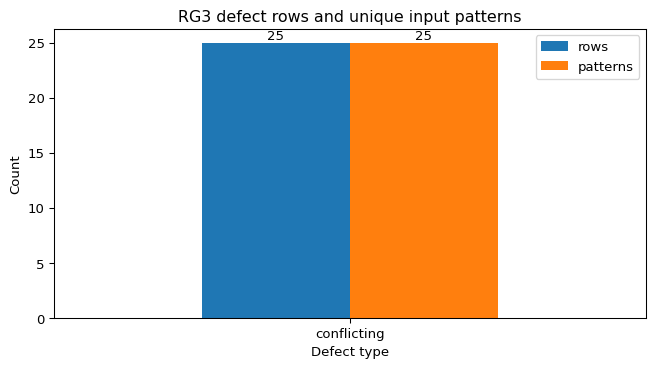

**결과:** 불량 25행 중 25행은 동일 입력의 양품이 존재한다. 나머지 0행의 ID는 []이며 0개 고유 패턴이다. 기존 불량 우선 처리는 충돌 조건의 양품을 제거하므로 원본의 관측 불량률이나 분리 가능성과 동일하게 해석하지 않는다.

In [39]:
eda3_type_summary = eda3_patterns.groupby('type').agg(
    patterns=('rows','size'), rows=('rows','sum'), normal_rows=('normal','sum'), defect_rows=('defects','sum'))
display(eda3_type_summary)
eda3_bad_cases = eda3_bad[['source_id','pattern_id','pattern_type']].copy()
eda3_bad_cases['same_input_normal_rows'] = eda3_bad.pattern_id.map(eda3_patterns.normal)
eda3_bad_cases['same_input_defect_rows'] = eda3_bad.pattern_id.map(eda3_patterns.defects)
display(eda3_bad_cases)
display(pd.DataFrame([
    ['Original rows', len(eda3_raw), len(eda3_normal), len(eda3_bad)],
    ['Unique X + label', len(eda3_normal_unique)+len(eda3_bad_unique), len(eda3_normal_unique), len(eda3_bad_unique)],
    ['Existing defect-priority X', len(eda3_current), int(eda3_current.PassOrFail.eq(0).sum()), int(eda3_current.PassOrFail.eq(1).sum())]
], columns=['view','total','normal','defect']))
fig, ax = plt.subplots(figsize=(7,4))
eda3_bad.groupby('pattern_type').agg(rows=('pattern_id','size'), patterns=('pattern_id','nunique')).plot.bar(ax=ax, rot=0)
ax.set(title='RG3 defect rows and unique input patterns', ylabel='Count', xlabel='Defect type')
for container in ax.containers: ax.bar_label(container)
plt.tight_layout(); plt.show()
eda3_shared_n = int(eda3_bad.pattern_type.eq('conflicting').sum())
eda3_only_ids = eda3_bad.loc[eda3_bad.pattern_type.eq('defect_only'),'source_id'].tolist()
eda3_say(f'**결과:** 불량 {len(eda3_bad)}행 중 {eda3_shared_n}행은 동일 입력의 양품이 존재한다. '
         f'나머지 {len(eda3_bad)-eda3_shared_n}행의 ID는 {eda3_only_ids}이며 '
         f'{eda3_bad.loc[eda3_bad.pattern_type.eq("defect_only"),"pattern_id"].nunique()}개 고유 패턴이다. '
         '기존 불량 우선 처리는 충돌 조건의 양품을 제거하므로 원본의 관측 불량률이나 분리 가능성과 동일하게 해석하지 않는다.')

**해석과 다음 단계:** RG3의 불량 25행은 모두 서로 다른 충돌 패턴 25개에 속하며, 각 패턴에 동일 입력의 양품이 1행씩 있다. 비충돌 불량은 0개다. 나머지 566개 패턴은 양품이 각각 2행이다. 따라서 현재 24개 입력을 사용하는 결정적 규칙으로 충돌 패턴 안의 두 행에 서로 다른 답을 줄 수 없다. 이 결과만으로 검수 오류인지, 미측정 조건인지, 데이터 구성 과정의 영향인지 구분할 수는 없다.

A.2의 정확한 좌표 겹침은 이 구조상 모든 쌍에서 남을 것이므로 새로운 분리 근거가 될 수 없다. 조합 분석은 이를 확인하고, 넓은 구간에서 불량의 관측 빈도가 상대적으로 높은 조건이 있는지 점검하는 용도로 제한한다.

## A.2 상위 변수 조합의 추가 정보와 한계

**질문:** 단일 변수보다 두 변수의 조합이 더 유용한 정보를 주는가?

KS는 개별 변수의 분포 차이만 보여준다. 따라서 상위 5개의 10개 쌍에서 각 단일 값은 양품에 있지만 두 값의 조합은 없는 사례가 있는지 비교한다. 다만 RG3는 전체입력이 같은 양품이 모든 불량에 존재하므로, 정확한 값의 조합으로 새로 분리할 수 있는 사례는 없을 것으로 예상된다. 이를 10개 쌍에서 확인한 뒤 구간별 집중 정도를 별도로 해석한다.

파란 점은 양품 고유 전체입력 패턴, 주황색 빈 원은 충돌 불량, 빨간 ×는 비충돌 불량이다. RG3에는 빨간 ×에 해당하는 사례가 없다. Spearman 상관은 양품 고유 패턴에서 계산하며, 높은 상관을 독립적인 두 불량 원인으로 세지 않는다.

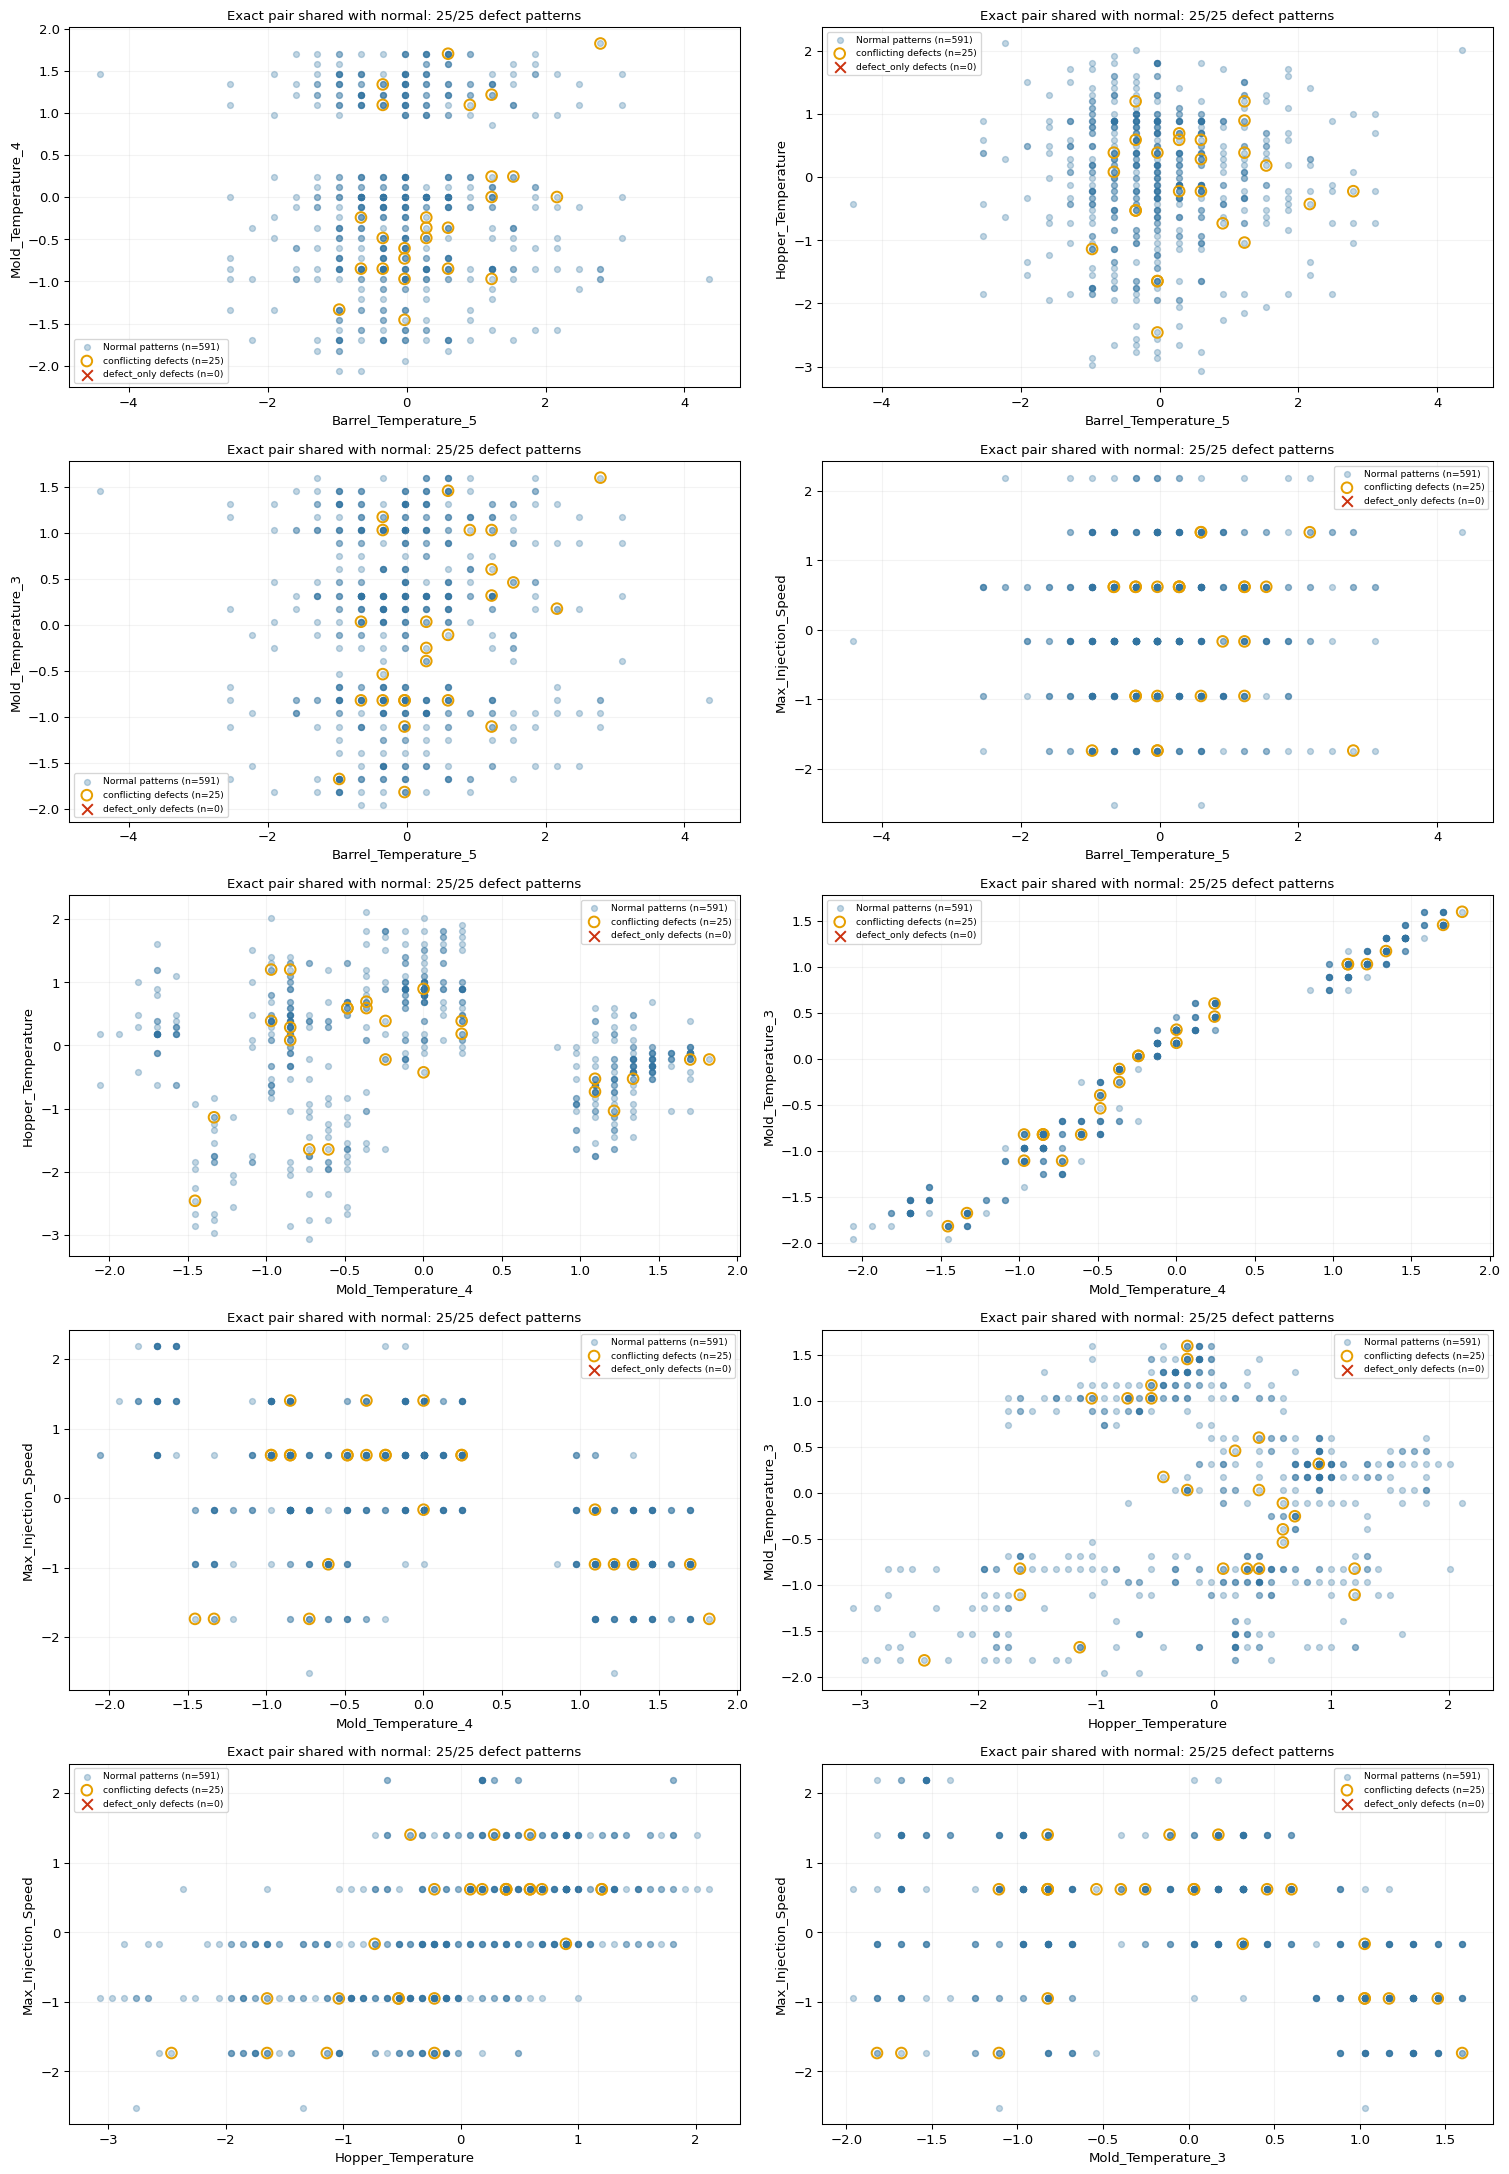

,feature_1,feature_2,normal_pattern_spearman,defect_patterns,shared_with_normal,no_exact_normal_pair
0,Barrel_Temperature_5,Mold_Temperature_4,0.073,25,25,0
1,Barrel_Temperature_5,Hopper_Temperature,-0.003,25,25,0
2,Barrel_Temperature_5,Mold_Temperature_3,0.074,25,25,0
3,Barrel_Temperature_5,Max_Injection_Speed,0.092,25,25,0
4,Mold_Temperature_4,Hopper_Temperature,-0.088,25,25,0
5,Mold_Temperature_4,Mold_Temperature_3,0.987,25,25,0
6,Mold_Temperature_4,Max_Injection_Speed,-0.492,25,25,0
7,Hopper_Temperature,Mold_Temperature_3,-0.030,25,25,0
8,Hopper_Temperature,Max_Injection_Speed,0.563,25,25,0
9,Mold_Temperature_3,Max_Injection_Speed,-0.434,25,25,0


feature_1                      Barrel_Temperature_5  ...  Mold_Temperature_3
feature_2                        Mold_Temperature_4  ... Max_Injection_Speed
representative_id pattern_type                       ...                    
1347              conflicting                     1  ...                  15
1371              conflicting                    13  ...                  39
1381              conflicting                    17  ...                  39
1415              conflicting                    21  ...                  39
1455              conflicting                     7  ...                  13
1511              conflicting                     5  ...                   5
1515              conflicting                     7  ...                   1
1521              conflicting                     5  ...                   7
1533              conflicting                     1  ...                  13
1557              conflicting                     1  ...                  22
1618              conflicting                     1  ...                  21
1621              conflicting                     5  ...                  22
1674              conflicting                     7  ...                  55
1761              conflicting                     3  ...                  19
1831              conflicting                     1  ...                  17
1897              conflicting                     1  ...                   3
1937              conflicting                     7  ...                   1
1973              conflicting                     5  ...                   5
2021              conflicting                    11  ...                  23
2105              conflicting                     1  ...                  25
2163              conflicting                     5  ...                  23
2177              conflicting                     3  ...                  50
2183              conflicting                     7  ...                  50
2331              conflicting                    11  ...                  27
2343              conflicting                     1  ...                   3

[25 rows x 10 columns]

**겹침과 중복 정보:** 아래 표는 양품 고유 패턴에서 |Spearman|≥0.8인 쌍이다. 0.8은 관계를 요약하기 위한 표시 기준이다. 높은 상관은 두 변수가 비슷한 순서 정보를 가질 수 있음을 뜻하며, 독립적인 불량 요인 두 개를 발견했다는 의미는 아니다.

,feature_1,feature_2,normal_pattern_spearman
5,Mold_Temperature_4,Mold_Temperature_3,0.987


10개 쌍에서 동일 조합의 양품이 존재하는 불량 패턴 수는 25–25/25개다. RG3는 불량 전체가 충돌 패턴이므로 정확한 좌표 겹침으로는 분리할 수 없다. 구간별 빈도 차이는 다음 표에서 별도로 확인한다.

In [40]:
eda3_pair_rows = []
eda3_pair_details = []
fig, axes = plt.subplots(5, 2, figsize=(16,23))
for ax, (x,y) in zip(axes.flat, combinations(eda3_top5, 2)):
    eda3_scatter(ax, x, y)
    freq = eda3_normal.groupby([x,y]).size()
    counts = np.array([freq.get(tuple(v),0) for v in eda3_bad_unique[[x,y]].to_numpy()])
    eda3_pair_rows.append([x,y,eda3_normal_unique[[x,y]].corr(method='spearman').iloc[0,1],
                           len(counts),int((counts>0).sum()),int((counts==0).sum())])
    for (_,r), count in zip(eda3_bad_unique.iterrows(), counts):
        eda3_pair_details.append([x,y,int(r.source_id),int(r.pattern_id),r.pattern_type,int(count),
                                  int(eda3_patterns.loc[r.pattern_id,'defects'])])
    ax.set_title(f'Exact pair shared with normal: {(counts>0).sum()}/{len(counts)} defect patterns', fontsize=10)
plt.tight_layout(); plt.show()
eda3_pair_summary = pd.DataFrame(eda3_pair_rows, columns=[
    'feature_1','feature_2','normal_pattern_spearman','defect_patterns','shared_with_normal','no_exact_normal_pair'])
eda3_pair_detail = pd.DataFrame(eda3_pair_details, columns=[
    'feature_1','feature_2','representative_id','pattern_id','pattern_type','normal_rows_matching_pair','defect_rows_in_pattern'])
display(eda3_pair_summary.round(3))
display(eda3_pair_detail.pivot(index=['representative_id','pattern_type'], columns=['feature_1','feature_2'], values='normal_rows_matching_pair'))
eda3_strong = eda3_pair_summary.loc[eda3_pair_summary.normal_pattern_spearman.abs().ge(.8), ['feature_1','feature_2','normal_pattern_spearman']]
eda3_say('**겹침과 중복 정보:** 아래 표는 양품 고유 패턴에서 |Spearman|≥0.8인 쌍이다. '
         '0.8은 관계를 요약하기 위한 표시 기준이다. 높은 상관은 두 변수가 비슷한 순서 정보를 가질 수 있음을 뜻하며, 독립적인 불량 요인 두 개를 발견했다는 의미는 아니다.')
display(eda3_strong.round(3))
eda3_say(f'10개 쌍에서 동일 조합의 양품이 존재하는 불량 패턴 수는 '
         f'{eda3_pair_summary.shared_with_normal.min()}–{eda3_pair_summary.shared_with_normal.max()}/{len(eda3_bad_unique)}개다. '
         'RG3는 불량 전체가 충돌 패턴이므로 정확한 좌표 겹침으로는 분리할 수 없다. 구간별 빈도 차이는 다음 표에서 별도로 확인한다.')

In [41]:
# 조합의 추가 정보: 두 단일 값은 양품에 있지만 두 값의 조합은 없는가?
eda3_increment_rows = []
for x, y in combinations(eda3_top5, 2):
    x_absent = ~eda3_bad_unique[x].isin(eda3_normal[x])
    y_absent = ~eda3_bad_unique[y].isin(eda3_normal[y])
    freq = eda3_normal.groupby([x, y]).size()
    pair_absent = pd.Series(
        [freq.get(tuple(v), 0) == 0 for v in eda3_bad_unique[[x, y]].to_numpy()],
        index=eda3_bad_unique.index)
    additional = pair_absent & ~x_absent & ~y_absent
    eda3_increment_rows.append([
        x, y, int(x_absent.sum()), int(y_absent.sum()), int(pair_absent.sum()),
        int(additional.sum()), eda3_bad_unique.loc[additional, 'source_id'].tolist()])
eda3_pair_increment = pd.DataFrame(eda3_increment_rows, columns=[
    'feature_1', 'feature_2', 'x_alone_absent', 'y_alone_absent',
    'pair_absent', 'additional_over_two_singles', 'additional_representative_IDs'])
display(eda3_pair_increment)


,feature_1,feature_2,x_alone_absent,y_alone_absent,pair_absent,additional_over_two_singles,additional_representative_IDs
0,Barrel_Temperature_5,Mold_Temperature_4,0,0,0,0,[]
1,Barrel_Temperature_5,Hopper_Temperature,0,0,0,0,[]
2,Barrel_Temperature_5,Mold_Temperature_3,0,0,0,0,[]
3,Barrel_Temperature_5,Max_Injection_Speed,0,0,0,0,[]
4,Mold_Temperature_4,Hopper_Temperature,0,0,0,0,[]
5,Mold_Temperature_4,Mold_Temperature_3,0,0,0,0,[]
6,Mold_Temperature_4,Max_Injection_Speed,0,0,0,0,[]
7,Hopper_Temperature,Mold_Temperature_3,0,0,0,0,[]
8,Hopper_Temperature,Max_Injection_Speed,0,0,0,0,[]
9,Mold_Temperature_3,Max_Injection_Speed,0,0,0,0,[]


**조합 분석의 실제 결론:** 10개 쌍 모두 불량 25개 패턴 전체가 동일한 두 변수 값을 가진 양품과 겹친다. 단일 값이 양품에 없는 불량도 0개, 두 값을 조합해 추가로 드러나는 불량도 0개다. 이는 A.1의 전체입력 충돌로부터 예상한 결과이며, 조합 탐색으로 새로운 불량 판정 조건을 찾았다고 볼 수 없다.

`Mold_Temperature_3`와 `Mold_Temperature_4`의 Spearman 상관은 0.987이다. 두 온도는 양품 패턴에서 비슷한 순서 정보를 주므로, 두 변수가 상위에 있다는 사실을 서로 독립적인 두 원인의 증거로 보지 않는다. 다만 높은 상관만으로 어느 하나를 삭제하지 않고 모델 검증에 맡긴다.

### 두 변수 구간별 관측 건수: 불량이 집중되는 범위는 좁아지는가?
정확한 값의 겹침만으로는 주변 구간의 관측 빈도를 알 수 없다. 이번에는 양품 원본 중앙값으로 각 쌍을 네 구간으로 나누고, 불량이 포함된 구간의 크기와 양품 수를 확인한다. 단일 변수 구간과 비교해야 조합으로 범위가 얼마나 좁아졌는지 알 수 있으므로 뒤에 비교표를 추가한다.

경계와 같은 값은 `≤ median`에 포함한다. 이산값·동률 때문에 구간 크기는 같지 않을 수 있다. 각 칸은 **불량 행/전체 행, 전체입력 패턴 수**를 표시한다. 중앙값은 탐색용 구분이며 최적 불량 임계값이 아니다. 원본 중복을 유지한 관측 비율로, 독립 표본 기반 확률 추정은 아니다.


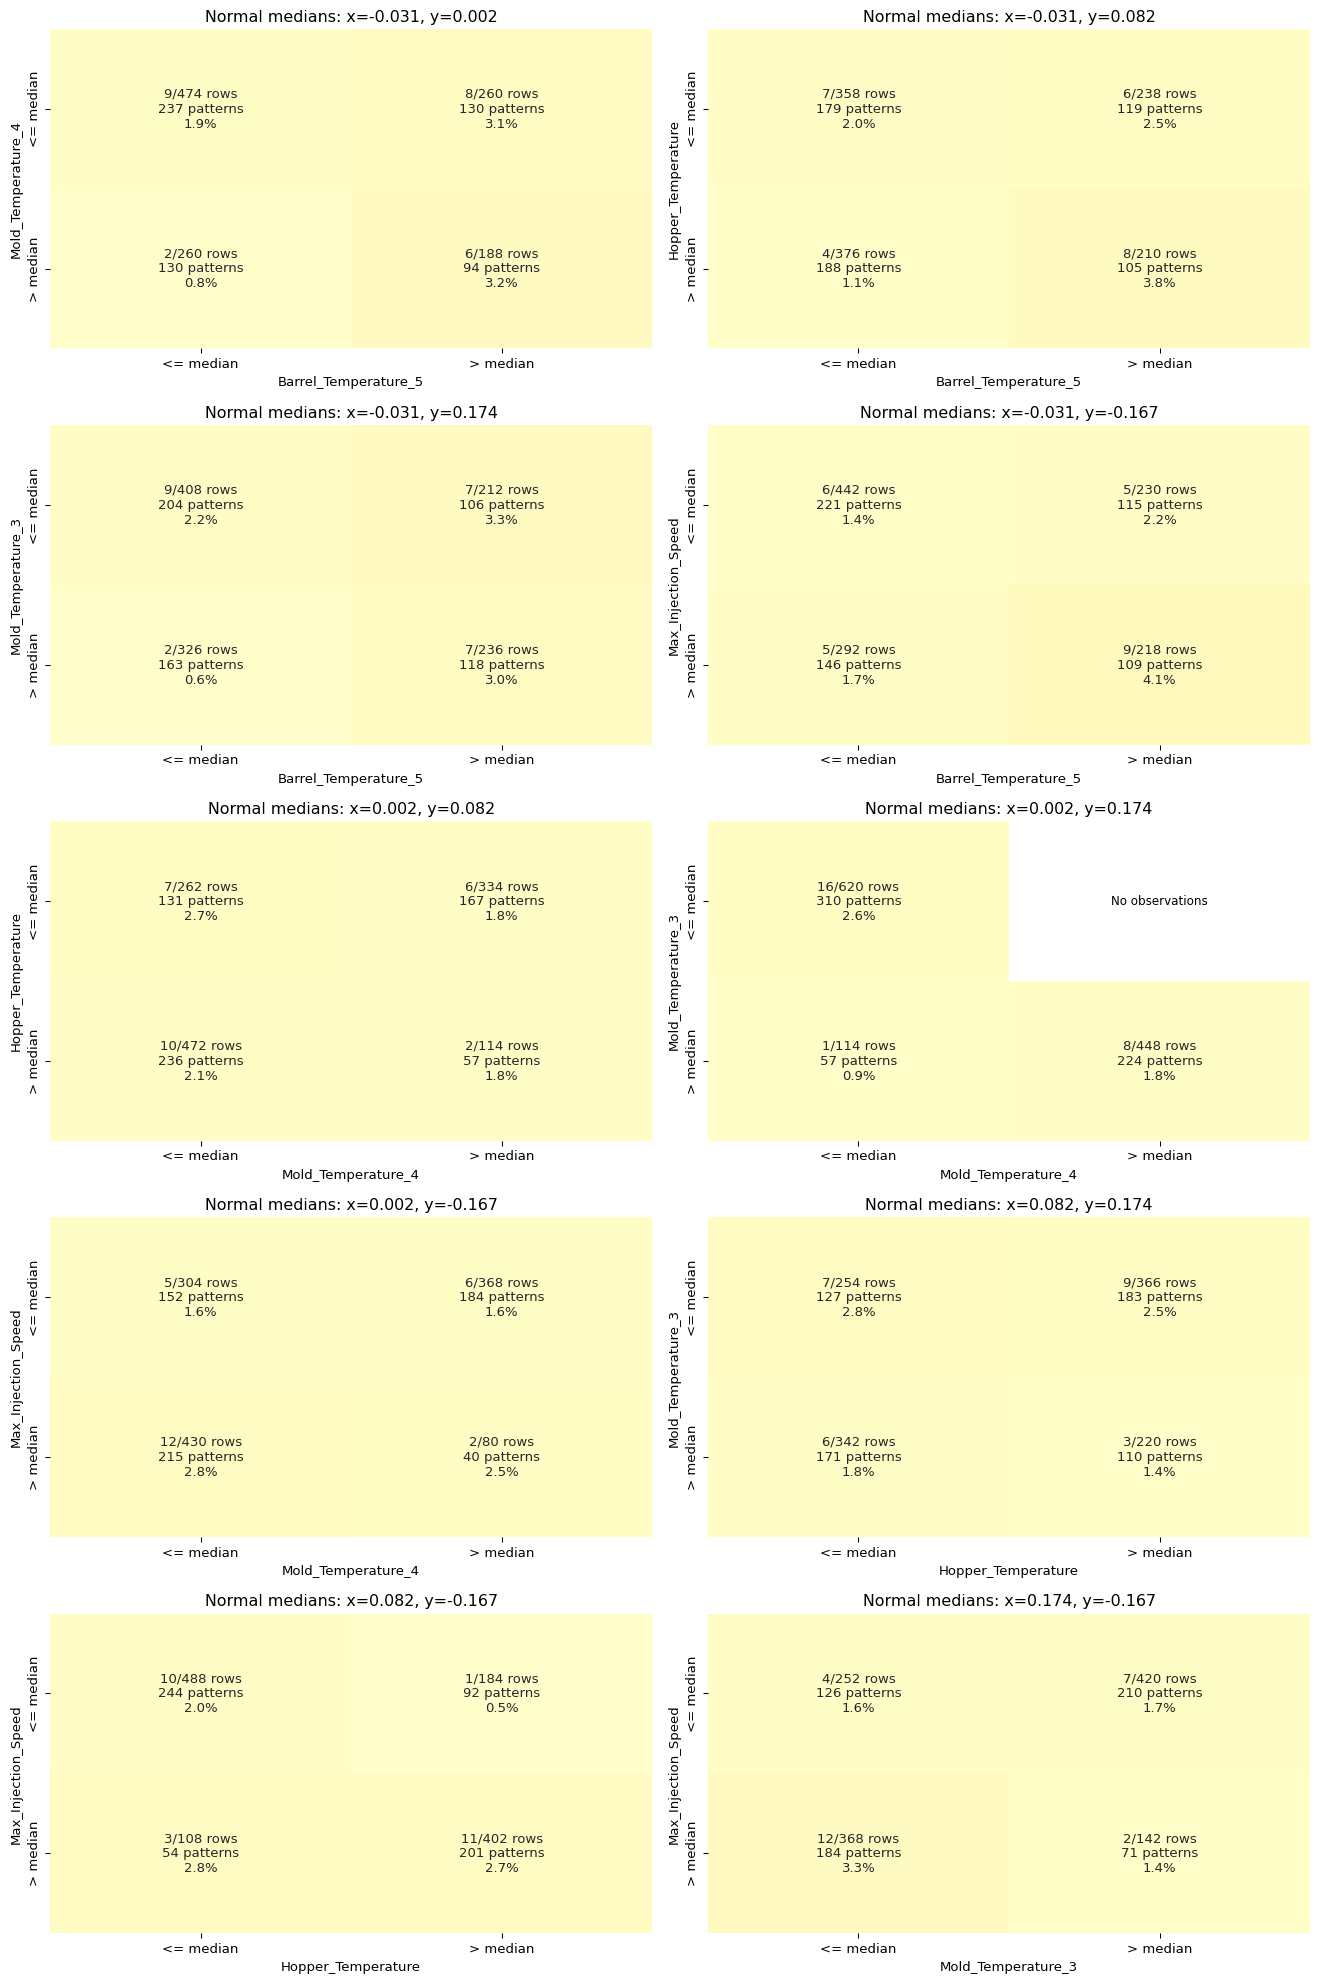

,feature_1,feature_2,x_cut,y_cut,x_high,y_high,rows,defects,patterns,observed_defect_fraction
0,Barrel_Temperature_5,Mold_Temperature_4,-0.030765,0.002053,0,0,474,9,237,0.018987
1,Barrel_Temperature_5,Mold_Temperature_4,-0.030765,0.002053,1,0,260,8,130,0.030769
2,Barrel_Temperature_5,Mold_Temperature_4,-0.030765,0.002053,0,1,260,2,130,0.007692
3,Barrel_Temperature_5,Mold_Temperature_4,-0.030765,0.002053,1,1,188,6,94,0.031915
4,Barrel_Temperature_5,Hopper_Temperature,-0.030765,0.081547,0,0,358,7,179,0.019553
5,Barrel_Temperature_5,Hopper_Temperature,-0.030765,0.081547,1,0,238,6,119,0.025210
6,Barrel_Temperature_5,Hopper_Temperature,-0.030765,0.081547,0,1,376,4,188,0.010638
7,Barrel_Temperature_5,Hopper_Temperature,-0.030765,0.081547,1,1,210,8,105,0.038095
8,Barrel_Temperature_5,Mold_Temperature_3,-0.030765,0.173825,0,0,408,9,204,0.022059
9,Barrel_Temperature_5,Mold_Temperature_3,-0.030765,0.173825,1,0,212,7,106,0.033019


**해석:** 같은 색의 차이도 분모와 고유 패턴 수를 먼저 확인한다. 불량이 포함된 구간에 양품도 많다면 그 조합은 점검할 조건을 설명하지만 단독 판정 규칙으로는 부족하다. KS 상위 변수 선정과 이 구간 비교는 같은 데이터를 사용했으므로 독립 검증이 아니다.

In [42]:
eda3_quadrants = []
fig, axes = plt.subplots(5,2,figsize=(14,21))
for ax,(x,y) in zip(axes.flat, combinations(eda3_top5,2)):
    mx,my = eda3_normal[x].median(),eda3_normal[y].median()
    rates = np.full((2,2),np.nan); labels = np.empty((2,2),dtype=object)
    for iy in range(2):
        for ix in range(2):
            mask = (eda3_raw[x].gt(mx) if ix else eda3_raw[x].le(mx)) & (eda3_raw[y].gt(my) if iy else eda3_raw[y].le(my))
            g=eda3_raw.loc[mask]; total=len(g); bad=int(g.PassOrFail.sum()); patterns=g.pattern_id.nunique()
            rate=bad/total if total else np.nan
            rates[iy,ix]=100*rate
            labels[iy,ix]=f'{bad}/{total} rows\n{patterns} patterns\n{100*rate:.1f}%' if total else 'No observations'
            eda3_quadrants.append([x,y,mx,my,ix,iy,total,bad,patterns,rate])
    sns.heatmap(rates,annot=labels,fmt='',cmap='YlOrRd',vmin=0,vmax=100,cbar=False,ax=ax,
                xticklabels=['<= median','> median'],yticklabels=['<= median','> median'])
    for iy,ix in zip(*np.where(np.isnan(rates))):ax.text(ix+.5,iy+.5,'No observations',ha='center',va='center',fontsize=9)
    ax.set(xlabel=x,ylabel=y,title=f'Normal medians: x={mx:.3f}, y={my:.3f}')
plt.tight_layout();plt.show()
eda3_quadrant_table=pd.DataFrame(eda3_quadrants,columns=['feature_1','feature_2','x_cut','y_cut','x_high','y_high','rows','defects','patterns','observed_defect_fraction'])
display(eda3_quadrant_table)
eda3_say('**해석:** 같은 색의 차이도 분모와 고유 패턴 수를 먼저 확인한다. '
         '불량이 포함된 구간에 양품도 많다면 그 조합은 점검할 조건을 설명하지만 단독 판정 규칙으로는 부족하다. '
         'KS 상위 변수 선정과 이 구간 비교는 같은 데이터를 사용했으므로 독립 검증이 아니다.')

In [43]:
# 단일 변수 구간과 두 변수 구간을 같은 원본 행 기준으로 비교한다.
eda3_single_regions = []
for c in eda3_top5:
    cut = eda3_normal[c].median()
    for high in [False, True]:
        g = eda3_raw[eda3_raw[c].gt(cut) if high else eda3_raw[c].le(cut)]
        if g.PassOrFail.sum() > 0:
            eda3_single_regions.append([c, '> median' if high else '<= median',
                len(g), int(g.PassOrFail.sum()), g.pattern_id.nunique(),
                g.PassOrFail.mean()])
eda3_single_region_table = pd.DataFrame(eda3_single_regions, columns=[
    'feature', 'region', 'rows', 'defects', 'patterns', 'observed_defect_fraction'])
display(eda3_single_region_table)
display(eda3_quadrant_table.loc[eda3_quadrant_table.defects.gt(0), [
    'feature_1', 'feature_2', 'x_high', 'y_high', 'rows', 'defects', 'patterns',
    'observed_defect_fraction']])


,feature,region,rows,defects,patterns,observed_defect_fraction
0,Barrel_Temperature_5,<= median,734,11,367,0.014986
1,Barrel_Temperature_5,> median,448,14,224,0.031250
2,Mold_Temperature_4,<= median,734,17,367,0.023161
3,Mold_Temperature_4,> median,448,8,224,0.017857
4,Hopper_Temperature,<= median,596,13,298,0.021812
5,Hopper_Temperature,> median,586,12,293,0.020478
6,Mold_Temperature_3,<= median,620,16,310,0.025806
7,Mold_Temperature_3,> median,562,9,281,0.016014
8,Max_Injection_Speed,<= median,672,11,336,0.016369
9,Max_Injection_Speed,> median,510,14,255,0.027451


,feature_1,feature_2,x_high,y_high,rows,defects,patterns,observed_defect_fraction
0,Barrel_Temperature_5,Mold_Temperature_4,0,0,474,9,237,0.018987
1,Barrel_Temperature_5,Mold_Temperature_4,1,0,260,8,130,0.030769
2,Barrel_Temperature_5,Mold_Temperature_4,0,1,260,2,130,0.007692
3,Barrel_Temperature_5,Mold_Temperature_4,1,1,188,6,94,0.031915
4,Barrel_Temperature_5,Hopper_Temperature,0,0,358,7,179,0.019553
5,Barrel_Temperature_5,Hopper_Temperature,1,0,238,6,119,0.025210
6,Barrel_Temperature_5,Hopper_Temperature,0,1,376,4,188,0.010638
7,Barrel_Temperature_5,Hopper_Temperature,1,1,210,8,105,0.038095
8,Barrel_Temperature_5,Mold_Temperature_3,0,0,408,9,204,0.022059
9,Barrel_Temperature_5,Mold_Temperature_3,1,0,212,7,106,0.033019


**구간 분석의 실제 결론:** 전체 불량 비율은 25/1,182행(2.12%)이다. 10개 쌍의 중앙값 네 구간 중 가장 높은 관측 비율은 `Barrel_Temperature_5 > median` 및 `Max_Injection_Speed > median`의 **9/218행(4.13%), 109개 패턴**이다. 배럴 온도 5 하나의 높은 구간은 14/448행(3.13%), 최대 사출 속도 하나의 높은 구간은 14/510행(2.75%)다.

두 조건을 결합하면 관측 비율은 높아지지만 포함되는 불량은 14건에서 9건으로 줄어든다. 이 구간을 불량으로 판정하면 양품 209건도 포함하며, 전체 불량 25건 중 16건을 놓친다. 따라서 높은 비율만으로 좋은 판정 규칙이라고 할 수 없다. RG3는 각 상위 변수의 중앙값 양쪽 모두에 불량이 있어, CN7처럼 모든 불량이 한 방향의 구간에 모이는 구조도 아니다.

이 구간은 같은 자료에서 40개 칸을 살펴본 탐색 결과다. 전체 자료 대비 약 1.95배라는 관측 비율 차이는 독립 검증된 위험도나 공정 원인으로 해석하지 않는다. 다음 절에서는 중복 처리 방식에 따라 개별 변수의 분포 차이가 얼마나 달라지는지 확인한다.

## A.3 상위 변수의 개별 분포와 처리 방식별 민감도

**질문:** 기존 상위 변수의 분포 차이는 원본과 라벨별 고유 패턴에서도 유지되는가?

같은 5개 변수에 대해 원본 행, 불량 우선 처리, 라벨별 고유 패턴, 충돌 불량만을 비교한다. 비충돌 불량은 0행이므로 그 집단의 KS는 계산하지 않는다. 충돌 불량만의 비교는 원본 불량 전체와 같은 집단이라는 점을 명시한다.

,view,feature,normal_n,defect_n,KS,normal_median,defect_median
0,Original rows,Barrel_Temperature_5,1157,25,0.184892,-0.030765,0.282727
1,Original rows,Mold_Temperature_4,1157,25,0.165255,0.002053,-0.362122
2,Original rows,Hopper_Temperature,1157,25,0.147692,0.081547,0.081547
3,Original rows,Mold_Temperature_3,1157,25,0.142783,0.173825,-0.111141
4,Original rows,Max_Injection_Speed,1157,25,0.131305,-0.167384,0.617645
5,Existing defect-priority,Barrel_Temperature_5,566,25,0.188975,-0.030765,0.282727
6,Existing defect-priority,Mold_Temperature_4,566,25,0.168905,0.002053,-0.362122
7,Existing defect-priority,Hopper_Temperature,566,25,0.150954,0.081547,0.081547
8,Existing defect-priority,Mold_Temperature_3,566,25,0.145936,0.173825,-0.111141
9,Existing defect-priority,Max_Injection_Speed,566,25,0.134205,-0.167384,0.617645


view,Conflicting defects only,Existing defect-priority,Original rows,Unique within label
feature,,,,
Barrel_Temperature_5,0.185,0.189,0.185,0.181
Mold_Temperature_4,0.165,0.169,0.165,0.162
Hopper_Temperature,0.148,0.151,0.148,0.145
Mold_Temperature_3,0.143,0.146,0.143,0.140
Max_Injection_Speed,0.131,0.134,0.131,0.129


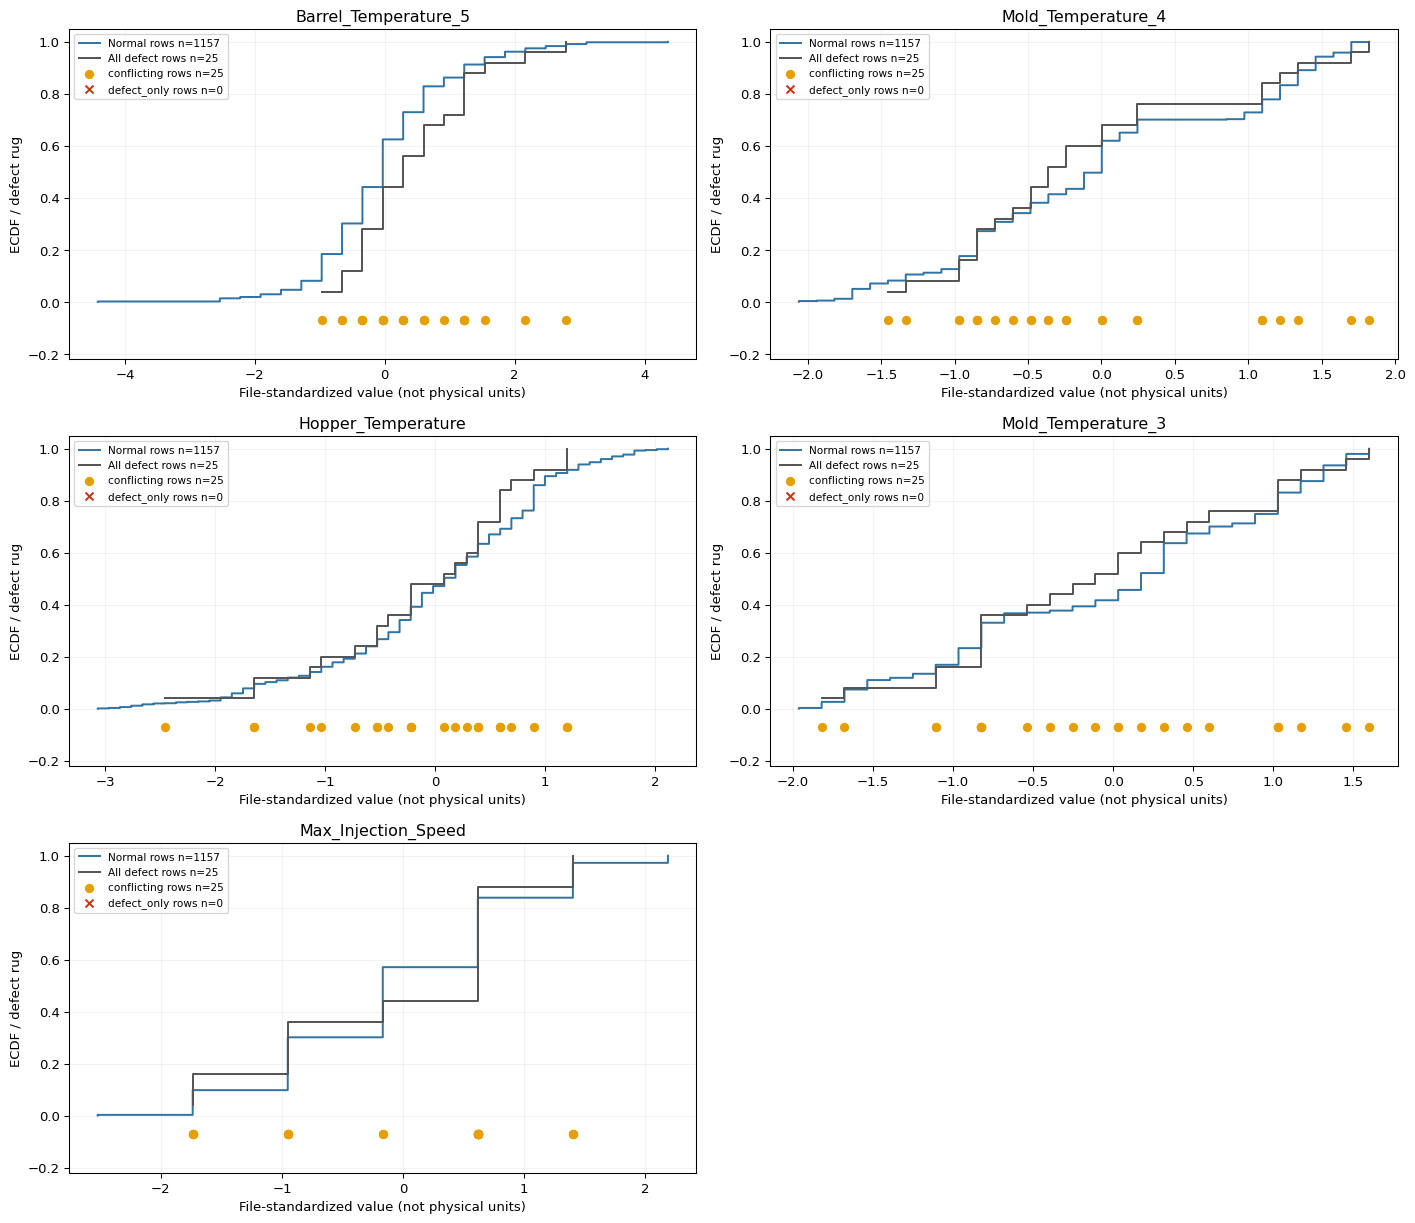

,feature,value,normal_rows,defect_rows,normal_patterns,defect_patterns,defect_IDs,observed_defect_fraction_at_value
0,Barrel_Temperature_5,-0.971148,119,1,60,1,[1937],0.008333
1,Barrel_Temperature_5,-0.657751,136,2,69,2,"[1371, 1621]",0.014493
2,Barrel_Temperature_5,-0.344258,162,4,83,4,"[1415, 1515, 2163, 2183]",0.024096
3,Barrel_Temperature_5,-0.030765,212,4,108,4,"[1381, 1897, 1973, 2021]",0.018519
4,Barrel_Temperature_5,0.282727,121,3,62,3,"[1511, 1533, 1557]",0.024194
...,...,...,...,...,...,...,...,...
60,Max_Injection_Speed,-1.737322,110,4,57,4,"[1897, 1937, 1973, 2343]",0.035088
61,Max_Injection_Speed,-0.952293,235,5,120,5,"[2021, 2163, 2177, 2183, 2331]",0.020833
62,Max_Injection_Speed,-0.167384,312,2,157,2,"[1674, 2105]",0.006369
63,Max_Injection_Speed,0.617645,309,11,160,11,"[1347, 1371, 1381, 1415, 1511, 1515, 1533, 155...",0.034375


**원본과 충돌 불량 비교:** RG3는 비충돌 불량이 없어 두 집단이 동일하다. 비충돌 집단의 KS는 계산하지 않는다.

- Barrel_Temperature_5: 원본 KS **0.185**, 불량 우선 **0.189**, 라벨별 고유 패턴 **0.181**.

- Mold_Temperature_4: 원본 KS **0.165**, 불량 우선 **0.169**, 라벨별 고유 패턴 **0.162**.

- Hopper_Temperature: 원본 KS **0.148**, 불량 우선 **0.151**, 라벨별 고유 패턴 **0.145**.

- Mold_Temperature_3: 원본 KS **0.143**, 불량 우선 **0.146**, 라벨별 고유 패턴 **0.140**.

- Max_Injection_Speed: 원본 KS **0.131**, 불량 우선 **0.134**, 라벨별 고유 패턴 **0.129**.

In [44]:
eda3_ks_rows=[]
eda3_views={
    'Original rows':(eda3_normal,eda3_bad),
    'Existing defect-priority':(eda3_current[eda3_current.PassOrFail.eq(0)],eda3_current[eda3_current.PassOrFail.eq(1)]),
    'Unique within label':(eda3_normal_unique,eda3_bad_unique),
    'Conflicting defects only':(eda3_normal,eda3_bad[eda3_bad.pattern_type.eq('conflicting')])}
for view,(normal,bad) in eda3_views.items():
    for c in eda3_top5:
        eda3_ks_rows.append([view,c,len(normal),len(bad),ks_2samp(normal[c],bad[c]).statistic,
                             normal[c].median(),bad[c].median()])
eda3_ks_sensitivity=pd.DataFrame(eda3_ks_rows,columns=['view','feature','normal_n','defect_n','KS','normal_median','defect_median'])
display(eda3_ks_sensitivity)
eda3_ks_wide=eda3_ks_sensitivity.pivot(index='feature',columns='view',values='KS').reindex(eda3_top5)
display(eda3_ks_wide.round(3))
assert np.allclose(eda3_ks_wide['Existing defect-priority'],ks_df.set_index('Feature').loc[eda3_top5,'KS_Statistic'])
fig,axes=plt.subplots(3,2,figsize=(15,13))
for ax,c in zip(axes.flat,eda3_top5):
    for label,g,color in [('Normal rows',eda3_normal,'#3274A1'),('All defect rows',eda3_bad,'#555555')]:
        v=np.sort(g[c].to_numpy());ax.step(v,np.arange(1,len(v)+1)/len(v),where='post',label=f'{label} n={len(v)}',color=color)
    for kind,level,marker in [('conflicting',-.07,'o'),('defect_only',-.15,'x')]:
        g=eda3_bad[eda3_bad.pattern_type.eq(kind)]
        ax.scatter(g[c],np.full(len(g),level),color=eda3_colors[kind],marker=marker,label=f'{kind} rows n={len(g)}')
    ax.set(title=c,xlabel='File-standardized value (not physical units)',ylabel='ECDF / defect rug',ylim=(-.22,1.05))
    ax.legend(fontsize=8);ax.grid(alpha=.15)
axes.flat[-1].axis('off');plt.tight_layout();plt.show()

# 불량에서 관측된 실제 값별로 양품 빈도와 고유 전체입력 패턴 수를 표시한다.
eda3_value_rows=[]
for c in eda3_top5:
    for value,b in eda3_bad.groupby(c):
        a=eda3_normal[eda3_normal[c].eq(value)]
        eda3_value_rows.append([c,value,len(a),len(b),a.pattern_id.nunique(),b.pattern_id.nunique(),b.source_id.tolist(),len(b)/(len(a)+len(b))])
eda3_value_table=pd.DataFrame(eda3_value_rows,columns=['feature','value','normal_rows','defect_rows','normal_patterns','defect_patterns','defect_IDs','observed_defect_fraction_at_value'])
display(eda3_value_table)
eda3_say('**원본과 충돌 불량 비교:** RG3는 비충돌 불량이 없어 두 집단이 동일하다. 비충돌 집단의 KS는 계산하지 않는다.')
for c in eda3_top5:
    r = eda3_ks_wide.loc[c]
    eda3_say(f'- {c}: 원본 KS **{r["Original rows"]:.3f}**, '
             f'불량 우선 **{r["Existing defect-priority"]:.3f}**, '
             f'라벨별 고유 패턴 **{r["Unique within label"]:.3f}**.')


**데이터가 말하는 것:** 원본 KS는 배럴 온도 5 0.185, 금형 온도 4 0.165, 호퍼 온도 0.148, 금형 온도 3 0.143, 최대 사출 속도 0.131이다. 불량 우선 처리의 0.189·0.169·0.151·0.146·0.134보다 각각 조금 작다. 해당 처리에서 충돌 양품이 제거되며 분포 차이가 약간 커졌지만, 그것이 입력이 같은 양품·불량을 분리할 수 있게 해주는 것은 아니다.

충돌 불량만의 KS는 원본과 정확히 같다. 이는 특이 사례를 제외해도 경향이 유지되었다는 별도 증거가 아니라, 제외할 비충돌 불량이 없어서 같은 비교를 한 결과다. 불량에서 관측된 모든 개별 값은 양품에도 있고, 각 전체입력 패턴은 양품과 공존한다. 따라서 단일 값별 불량 비율이나 큰 순위 차이를 확정 임계값으로 바꾸지 않는다. 다음 절에서는 공정 단계별 관측 범위도 같은 결론인지 확인한다.

## A.4 공정 단계별 조합 비교

**질문:** 충전·사출·전환·계량·열적 조건에서 불량이 관측 양품 범위를 벗어나는가?

충전시간–최대사출속도, 사출시간–최대사출압력, 전환압력–쿠션위치, 계량위치–배압, 계량시간–위치에 더해 RG3에서 KS가 높은 배럴 온도 5–호퍼 온도를 확인한다. 각 쌍은 공정 해석을 위한 요약이며 인과적 순서나 공정 실패 원인을 증명하지 않는다. `Injection_Time`은 사출 공통 요약값이고, 전환압력과 쿠션 위치만으로 보압 유지 전체를 알 수는 없다. 금형 온도 3·4는 정의의 불확실성을 고려해 A.2의 열적 참고 변수로 남긴다.

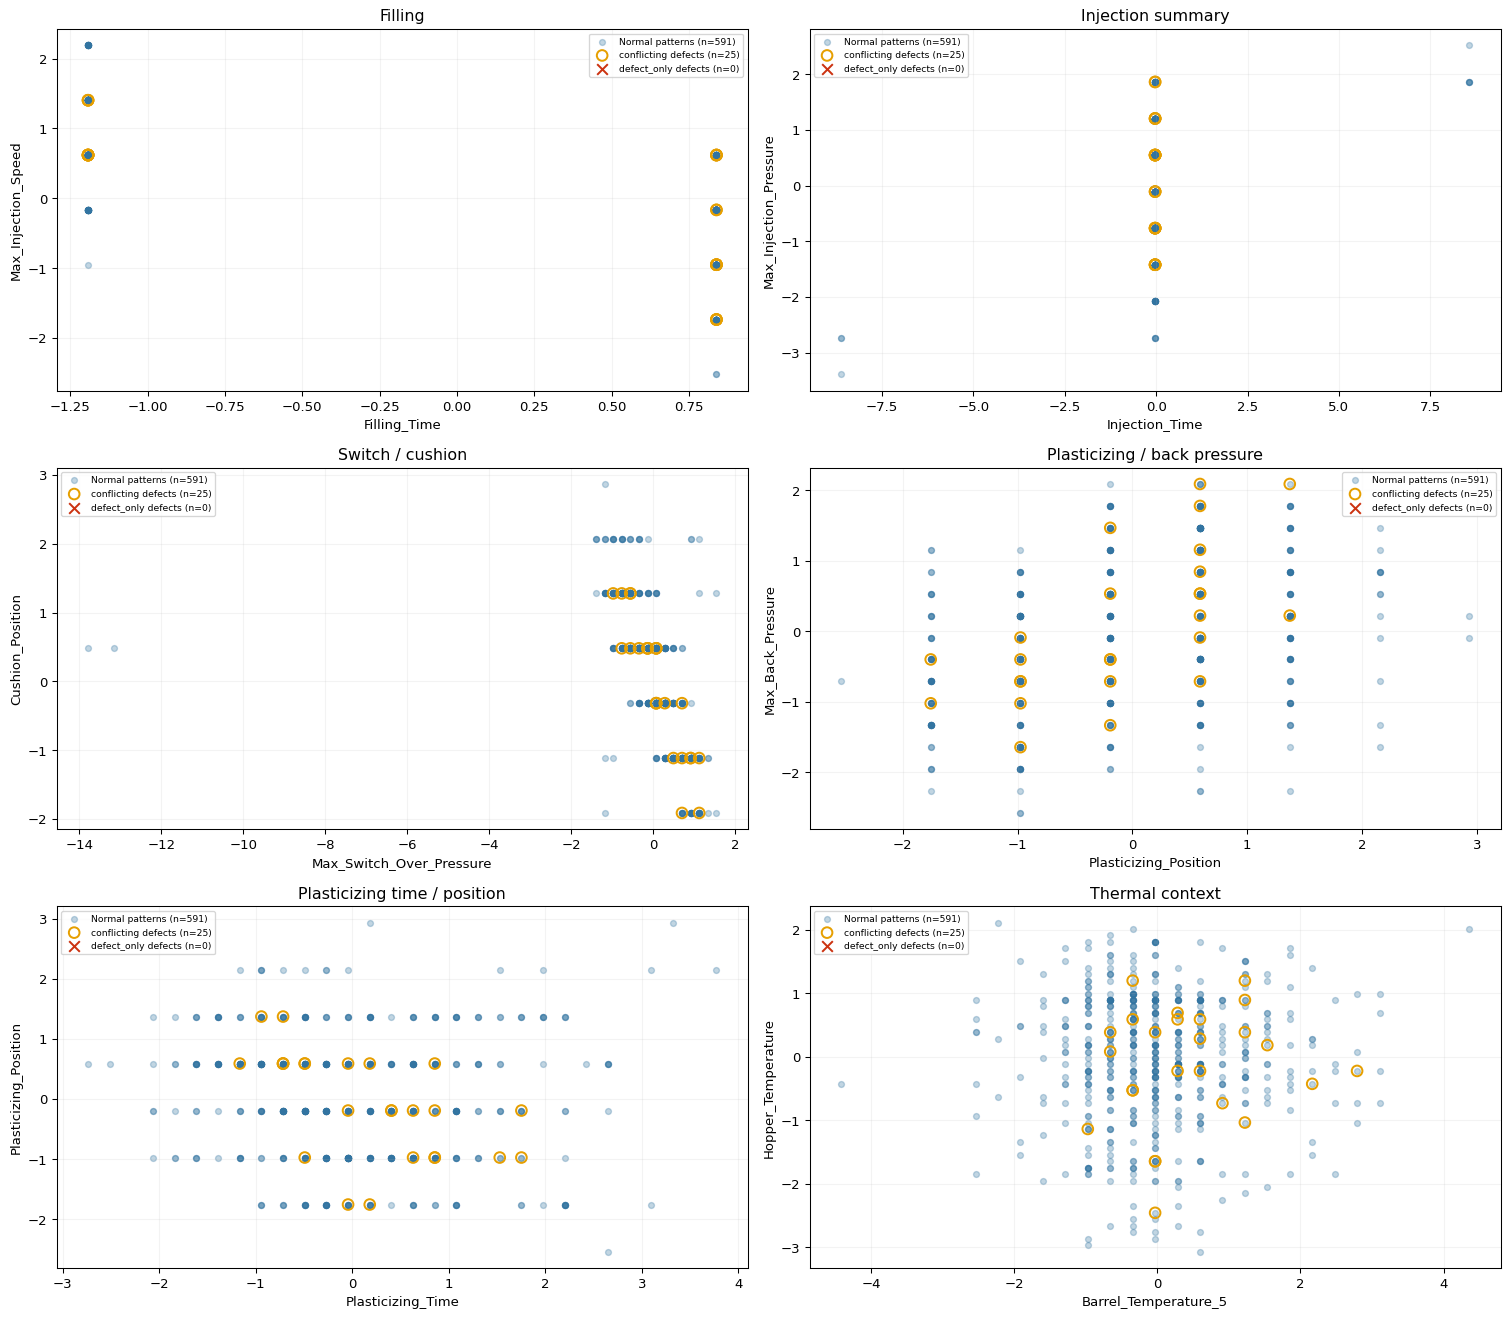

,,defect_patterns,pair_shared_with_normal,x_outside,y_outside
stage,type,,,,
Filling,conflicting,25,25,0,0
Injection summary,conflicting,25,25,0,0
Plasticizing / back pressure,conflicting,25,25,0,0
Plasticizing time / position,conflicting,25,25,0,0
Switch / cushion,conflicting,25,25,0,0
Thermal context,conflicting,25,25,0,0


**공정별 결과 — 전체 불량 고유 패턴 기준:**

- Filling: 25개 중 25개는 같은 조합의 양품이 있다. x 관측 양품 범위 밖 0개, y 범위 밖 0개.

- Injection summary: 25개 중 25개는 같은 조합의 양품이 있다. x 관측 양품 범위 밖 0개, y 범위 밖 0개.

- Switch / cushion: 25개 중 25개는 같은 조합의 양품이 있다. x 관측 양품 범위 밖 0개, y 범위 밖 0개.

- Plasticizing / back pressure: 25개 중 25개는 같은 조합의 양품이 있다. x 관측 양품 범위 밖 0개, y 범위 밖 0개.

- Plasticizing time / position: 25개 중 25개는 같은 조합의 양품이 있다. x 관측 양품 범위 밖 0개, y 범위 밖 0개.

- Thermal context: 25개 중 25개는 같은 조합의 양품이 있다. x 관측 양품 범위 밖 0개, y 범위 밖 0개.

In [45]:
eda3_process_pairs=[
    ('Filling','Filling_Time','Max_Injection_Speed'),
    ('Injection summary','Injection_Time','Max_Injection_Pressure'),
    ('Switch / cushion','Max_Switch_Over_Pressure','Cushion_Position'),
    ('Plasticizing / back pressure','Plasticizing_Position','Max_Back_Pressure'),
    ('Plasticizing time / position','Plasticizing_Time','Plasticizing_Position'),
    ('Thermal context','Barrel_Temperature_5','Hopper_Temperature')]
eda3_process_rows=[]
fig,axes=plt.subplots(3,2,figsize=(16,14))
for ax,(stage,x,y) in zip(axes.flat,eda3_process_pairs):
    eda3_scatter(ax,x,y);ax.set_title(stage)
    freq=eda3_normal.groupby([x,y]).size()
    for _,r in eda3_bad_unique.iterrows():
        eda3_process_rows.append([stage,int(r.source_id),int(r.pattern_id),r.pattern_type,
            int(freq.get((r[x],r[y]),0)),
            bool(r[x]<eda3_normal[x].min() or r[x]>eda3_normal[x].max()),
            bool(r[y]<eda3_normal[y].min() or r[y]>eda3_normal[y].max())])
plt.tight_layout();plt.show()
eda3_process_detail=pd.DataFrame(eda3_process_rows,columns=['stage','representative_id','pattern_id','type','normal_rows_matching_pair','x_outside_observed_normal_range','y_outside_observed_normal_range'])
eda3_process_summary=eda3_process_detail.groupby(['stage','type']).agg(
    defect_patterns=('pattern_id','size'),pair_shared_with_normal=('normal_rows_matching_pair',lambda s:int(s.gt(0).sum())),
    x_outside=('x_outside_observed_normal_range','sum'),y_outside=('y_outside_observed_normal_range','sum'))
display(eda3_process_summary)
eda3_say('**공정별 결과 — 전체 불량 고유 패턴 기준:**')
for stage, _, _ in eda3_process_pairs:
    g = eda3_process_detail[eda3_process_detail.stage.eq(stage)]
    eda3_say(f'- {stage}: {len(g)}개 중 {g.normal_rows_matching_pair.gt(0).sum()}개는 '
             f'같은 조합의 양품이 있다. x 관측 양품 범위 밖 {g.x_outside_observed_normal_range.sum()}개, '
             f'y 범위 밖 {g.y_outside_observed_normal_range.sum()}개.')


**공정 비교의 해석:** 6개 공정 쌍 모두 불량 25개 패턴이 같은 조합의 양품과 겹치며, 각 축에서 관측 양품 범위를 벗어나는 불량은 0개다. RG3에는 현재 값으로 식별되는 비충돌 특이 불량이 없다. 따라서 관측 양품 범위를 이용한 단순 이상값 규칙으로 불량을 찾는 접근에는 근거가 부족하다.

이는 공정에 원인이 없다는 뜻이 아니다. 현재 측정값과 해상도로는 해당 실패를 특정할 정보가 충분하지 않다는 뜻이다. 패턴 빈도에 따른 예측 가능성은 별도 검증할 수 있지만, 로트·시간·검수·측정 과정 등 추가 정보 없이 어느 조건이 실패를 일으켰다고 확정할 수 없다. 원본 라벨을 보존하고 관측된 데이터의 한계를 전처리 명세에 기록한다.